# Dataset distribution analysis (R&D for dataset adaptation and template building)

**Purpose.** Before any model is trained, quantify *how the six datasets differ as EEG signals* —
amplitude, spectrum, temporal structure, spatial structure, task signal — and test which
standardization transforms actually shrink those differences without destroying the task signal.
The output is evidence for building one **standard template** that every dataset is mapped onto.

**Two signal domains are analysed, because they answer different questions:**

| Domain | Source | What only this domain can show |
|---|---|---|
| **R — raw / native** | `preprocessing_pkg` loaders (the same package the export used), a capped, seeded sample of subjects per dataset | native sampling rate and bandwidth, mains line noise, 0–100 Hz spectrum, 1/f slope, DC / drift / high-pass, amplitude scale before CAR, reference signature, noisy channels |
| **E — exported** | your frozen export (`processed/`: 128 Hz, 8–32 Hz, CAR over the shared channels, µV, plus the stored per-trial z-score `X_z`), **all** eligible subjects | what the model will actually see; per-trial statistics; time-locked task signal; subject vs dataset variance; effect of each candidate transform |

**Guard rails (read before interpreting anything).**
- The **locked test subjects are excluded by default** (`ACFG.include_locked_test=False`). Looking at their distribution
  before the final study would be a form of peeking. Everything here is fitted on, and described over, the CV pool.
- Any quantity that could become a *fitted* part of the pipeline (dataset template, adapters) is evaluated with
  **subject-grouped folds** (fit on train subjects, score on held-out subjects).
- Transforms are labelled **inductive** (no target data needed), **subject-transductive** (needs unlabeled trials from the
  new subject) or **dataset-oracle** (uses the dataset label). Never mix them in one claim.
- The exported band is 8–32 Hz with a 2 Hz FIR transition, so bins at 8 and 32 Hz are attenuated. All spectral summaries use
  the clean range **9–31 Hz** (`PSD_BAND`) and bands mu 9–12, beta-low 13–20, beta-high 21–30 Hz.
- The export contains **no pre-cue baseline** (windows start at the cue), so envelope curves are relative to each trial's own mean
  motor-channel power (one scalar per trial and band, so the C3/C4 ratio — the lateralization — is preserved). They show *shape and
  lateralization*, not absolute ERD percentages, and because the reference is the trial's own mean, a strong late effect also lowers the
  reference: compare early and late windows as a pair, never in isolation.

**Outputs** (all under `<export>/analysis_distribution/`): `figures/*.png`, `tables/*.csv`, `template_v1.json`,
`distribution_report.json`, and resumable per-subject caches (`cache_R/`, `cache_E/`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from zipfile import ZipFile
import os
if os.path.exists("/content/preprocessing_pkg.zip") and not os.path.exists("/content/preprocessing_pkg"):
    with ZipFile("/content/preprocessing_pkg.zip", "r") as z:
        z.extractall(path="/content")
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [3]:
!pip install -q mne moabb scikit-learn seaborn pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 980.1/980.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 910.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/9

In [4]:
from pathlib import Path
PKG_SOURCE_DIR      = Path("/content/preprocessing_pkg")
RAW_DATA_DRIVE_ROOT = Path("/content/drive/MyDrive/MI_EEG_Datasets")            # contains an mne_data folder
EXPORT_ROOT         = Path("/content/drive/MyDrive/MI_EEG_Datasets/processed")  # the v3 export (STATUS.txt, data/, metadata/ ...)

assert EXPORT_ROOT.exists(), f"EXPORT_ROOT not found: {EXPORT_ROOT}"
assert (EXPORT_ROOT / "STATUS.txt").read_text().startswith("READY_FOR_TRAINING"), "export did not pass its own gate"
EXPECTED_PREPROC_ID = "b202f261d85f"      # the v3 export (8-32 Hz, 0-3 s, per-trial z-score). Set None to skip the check.
if EXPECTED_PREPROC_ID is not None:
    _pid = (EXPORT_ROOT / "config" / "preproc_id.txt").read_text().strip()
    assert _pid == EXPECTED_PREPROC_ID, f"preproc_id {_pid} != expected {EXPECTED_PREPROC_ID}: wrong export folder?"
ANALYSIS_ROOT = EXPORT_ROOT / "analysis_distribution"
print("EXPORT_ROOT  :", EXPORT_ROOT)
print("ANALYSIS_ROOT:", ANALYSIS_ROOT)

EXPORT_ROOT  : /content/drive/MyDrive/MI_EEG_Datasets/processed
ANALYSIS_ROOT: /content/drive/MyDrive/MI_EEG_Datasets/processed/analysis_distribution


In [5]:

import os, sys, json, time, hashlib, warnings, itertools, re
from dataclasses import dataclass, field, asdict
from pathlib import Path
import numpy as np, pandas as pd
import scipy.signal as sps, scipy.stats as spst, scipy.linalg as spl
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="All-NaN slice")   # raw PSD above a dataset's Nyquist is NaN by design
sns.set_theme(context="notebook", style="whitegrid", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "axes.spines.top": False, "axes.spines.right": False})


@dataclass
class AnalysisConfig:
    seed: int = 42
    include_locked_test: bool = False          # keep False: the locked test is never inspected
    # ---- exported domain (E)
    cache_version: str = "E1"
    max_trials_per_subject: int | None = None  # None = all trials in the shard
    welch_nperseg: int = 128                   # 1 s at 128 Hz -> 1 Hz bins
    welch_noverlap: int = 64
    acf_max_lag_sec: float = 0.5
    env_decim: int = 8                         # envelope decimation (128 Hz -> 16 Hz)
    env_trim_sec: float = 0.25                 # edges of the narrow-band envelope are shown trimmed
    # ---- decodability / transform lab
    cap_per_subject_decode: int = 100
    cap_per_subject_class: int = 120
    n_splits: int = 5
    n_boot: int = 100
    n_perm_null: int = 5
    cap_per_subject_null: int = 40
    # ---- raw native domain (R)
    raw_domain_enabled: bool = True
    raw_subjects_per_dataset: int = 6
    raw_max_seconds: float = 240.0
    raw_psd_fmax: float = 100.0
    raw_cache_version: str = "R1"

ACFG = AnalysisConfig()

BANDS = {"mu": (9.0, 12.0), "beta_low": (13.0, 20.0), "beta_high": (21.0, 30.0)}
PSD_BAND = (9.0, 31.0)              # clean range of the 8-32 Hz export (edge bins are attenuated by the filter)
MOTOR_NAMES = ["C3", "CZ", "C4"]

ANALYSIS_ROOT = Path(ANALYSIS_ROOT)
FIG_DIR, TAB_DIR = ANALYSIS_ROOT / "figures", ANALYSIS_ROOT / "tables"
CACHE_E, CACHE_R = ANALYSIS_ROOT / "cache_E", ANALYSIS_ROOT / "cache_R"
for d in (FIG_DIR, TAB_DIR, CACHE_E, CACHE_R):
    d.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"  saved {path.name}")

def save_table(df, name, index=True):
    path = TAB_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    print(f"  saved {path.name}")

def read_table(path):
    """Read a metadata table written as parquet (Colab/export) or, as a fallback, csv."""
    path = Path(path)
    if path.exists():
        return pd.read_parquet(path)
    alt = path.with_suffix(".csv")
    if alt.exists():
        return pd.read_csv(alt)
    raise FileNotFoundError(path)

rng_global = np.random.default_rng(ACFG.seed)
print("AnalysisConfig:", asdict(ACFG))

AnalysisConfig: {'seed': 42, 'include_locked_test': False, 'cache_version': 'E1', 'max_trials_per_subject': None, 'welch_nperseg': 128, 'welch_noverlap': 64, 'acf_max_lag_sec': 0.5, 'env_decim': 8, 'env_trim_sec': 0.25, 'cap_per_subject_decode': 100, 'cap_per_subject_class': 120, 'n_splits': 5, 'n_boot': 100, 'n_perm_null': 5, 'cap_per_subject_null': 40, 'raw_domain_enabled': True, 'raw_subjects_per_dataset': 6, 'raw_max_seconds': 240.0, 'raw_psd_fmax': 100.0, 'raw_cache_version': 'R1'}


## Section 1 — Load the frozen export's metadata and define the cohort

Everything geometric (sampling rate, window, channel set, shared channels) is read from the export's own files
(`metadata/stored_layout.json`, `channels/`, `config/experiment_config.json`) rather than hard-coded.
The **shared channels** are the channels really recorded in *all* datasets; they are the only channels on which
datasets can be compared like-for-like, so every cross-dataset statistic below uses them.

In [6]:
META_ROOT, CONFIG_ROOT, CHANNELS_ROOT, SPLITS_ROOT = (EXPORT_ROOT / "metadata", EXPORT_ROOT / "config",
                                                       EXPORT_ROOT / "channels", EXPORT_ROOT / "splits")
subjects_all = read_table(META_ROOT / "subjects.parquet")
exp_cfg = json.loads((CONFIG_ROOT / "experiment_config.json").read_text())
layout = json.loads((META_ROOT / "stored_layout.json").read_text())
TARGET_CHANNELS = json.loads((CHANNELS_ROOT / "target_channels.json").read_text())
_masks = np.load(CHANNELS_ROOT / "channel_masks.npz")
CHANNEL_MASKS = {k: _masks[k].astype(bool) for k in _masks.files}

FS = float(layout["target_sfreq"]); N_SAMPLES = int(layout["n_samples"])
MASTER_WINDOW = tuple(layout["master_window_sec"]); T_AXIS = MASTER_WINDOW[0] + np.arange(N_SAMPLES) / FS
assert len(TARGET_CHANNELS) == layout["n_channels"]

subjects_all["subject_key"] = subjects_all["dataset"] + ":" + subjects_all["subject_id"].astype(str)
locked = set(json.loads((SPLITS_ROOT / "locked_test_subjects.json").read_text()))
subjects_all["locked_test"] = subjects_all["subject_key"].isin(locked)
SUBJ = subjects_all if ACFG.include_locked_test else subjects_all[~subjects_all["locked_test"]]
SUBJ = SUBJ.sort_values(["dataset", "subject_id"]).reset_index(drop=True)

DATASETS = sorted(SUBJ["dataset"].unique())
PALETTE = dict(zip(DATASETS, sns.color_palette("tab10", len(DATASETS))))
SHARED_MASK = np.logical_and.reduce([CHANNEL_MASKS[d] for d in DATASETS])
SHARED_IDX = np.where(SHARED_MASK)[0]
SHARED_NAMES = [TARGET_CHANNELS[i] for i in SHARED_IDX]
S = len(SHARED_IDX)
MOTOR_SH = [SHARED_NAMES.index(c) for c in MOTOR_NAMES if c in SHARED_NAMES]       # indices INTO the shared list
MOTOR_USED = [SHARED_NAMES[i] for i in MOTOR_SH]
assert MOTOR_USED == MOTOR_NAMES, f"motor channels {MOTOR_NAMES} not all in shared set {SHARED_NAMES}"

print(f"export: fs={FS:.0f} Hz | window={MASTER_WINDOW} s | {N_SAMPLES} samples | {len(TARGET_CHANNELS)} target channels")
print(f"locked-test subjects excluded: {int(subjects_all['locked_test'].sum())} "
      f"(include_locked_test={ACFG.include_locked_test}) -> analysing {len(SUBJ)} subjects")
print(f"shared channels ({S}): {SHARED_NAMES}")
print("datasets:", DATASETS)

export: fs=128 Hz | window=(0.0, 3.0) s | 384 samples | 62 target channels
locked-test subjects excluded: 48 (include_locked_test=False) -> analysing 268 subjects
shared channels (18): ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CPZ', 'CZ', 'FC1', 'FC2', 'FC3', 'FC4', 'FZ', 'PZ']
datasets: ['bnci2014001', 'cho2017', 'dreyer2023', 'lee2019', 'physionet', 'weibo2014']


,subjects,trials,trials_per_subj_median,trials_per_subj_min,trials_per_subj_max,real_channels,native_sfreq,share_of_trials_%,left_frac
dataset,,,,,,,,,
bnci2014001,8,2304,288.0,288,288,22,250.0,5.3,0.500
cho2017,44,8920,200.0,200,240,62,512.0,20.6,0.500
dreyer2023,73,17520,240.0,240,240,27,512.0,40.5,0.500
lee2019,46,9200,200.0,200,200,48,1000.0,21.3,0.500
physionet,89,4003,45.0,43,45,62,160.0,9.3,0.505
weibo2014,8,1260,160.0,140,160,58,200.0,2.9,0.500


  saved 01_cohort_by_dataset.csv
  saved F01_cohort_inventory.png


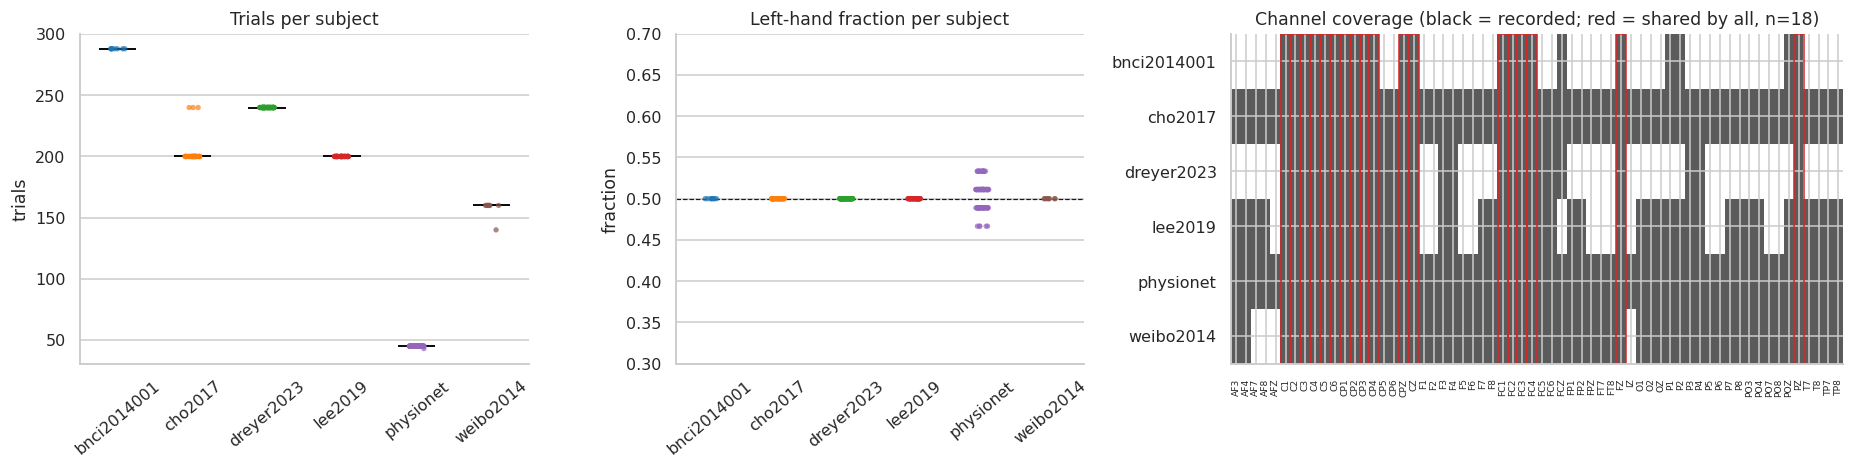

In [7]:
# Cohort table + Figure 1 (inventory)
def dreyer_feedback_rule(dataset, run_label):
    """Same rule the export used for trials.parquet:feedback_confounded."""
    return dataset == "dreyer2023" and not (("R1" in str(run_label)) or ("R2" in str(run_label)))

cohort = (SUBJ.groupby("dataset").agg(subjects=("subject_id", "size"), trials=("n_trials", "sum"),
          trials_per_subj_median=("n_trials", "median"), trials_per_subj_min=("n_trials", "min"),
          trials_per_subj_max=("n_trials", "max"), real_channels=("n_real_channels", "first"),
          native_sfreq=("native_sfreq", "first")))
cohort["share_of_trials_%"] = (100 * cohort["trials"] / cohort["trials"].sum()).round(1)
_agg = SUBJ.groupby("dataset")[["n_trials_left", "n_trials"]].sum()
cohort["left_frac"] = (_agg["n_trials_left"] / _agg["n_trials"]).round(3)
display(cohort)
save_table(cohort, "01_cohort_by_dataset")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4), gridspec_kw={"width_ratios": [1.1, 1, 1.5]})
sns.stripplot(data=SUBJ, x="dataset", y="n_trials", order=DATASETS, palette=PALETTE, size=3.5, alpha=.7, ax=ax[0])
sns.boxplot(data=SUBJ, x="dataset", y="n_trials", order=DATASETS, color="none", width=.5, fliersize=0, ax=ax[0])
ax[0].set(title="Trials per subject", xlabel="", ylabel="trials"); ax[0].tick_params(axis="x", rotation=40)
bal = SUBJ.assign(left_frac=SUBJ["n_trials_left"] / SUBJ["n_trials"])
sns.stripplot(data=bal, x="dataset", y="left_frac", order=DATASETS, palette=PALETTE, size=3.5, alpha=.7, ax=ax[1])
ax[1].axhline(.5, color="k", lw=.8, ls="--"); ax[1].set(title="Left-hand fraction per subject", xlabel="", ylabel="fraction", ylim=(.3, .7))
ax[1].tick_params(axis="x", rotation=40)
cov = np.array([CHANNEL_MASKS[d] for d in DATASETS]).astype(float)
ax[2].imshow(cov, aspect="auto", cmap="Greys", vmin=0, vmax=1.4)
for j in SHARED_IDX:
    ax[2].add_patch(plt.Rectangle((j - .5, -.5), 1, len(DATASETS), fill=False, ec="tab:red", lw=1.0))
ax[2].set_yticks(range(len(DATASETS))); ax[2].set_yticklabels(DATASETS)
ax[2].set_xticks(range(len(TARGET_CHANNELS))); ax[2].set_xticklabels(TARGET_CHANNELS, rotation=90, fontsize=6)
ax[2].set_title(f"Channel coverage (black = recorded; red = shared by all, n={S})")
fig.tight_layout(); save_fig(fig, "F01_cohort_inventory"); plt.show()

In [8]:
# Dreyer feedback-flag check -- resolves the open item "is feedback_confounded correct?" against the real run labels
try:
    trials_meta = read_table(META_ROOT / "trials.parquet")
    drey = trials_meta[trials_meta["dataset"] == "dreyer2023"]
    chk = (drey.groupby("run_label").agg(trials=("run_label", "size"), flagged=("feedback_confounded", "all"),
                                         any_flag=("feedback_confounded", "any")))
    display(chk)
    expected = drey["run_label"].map(lambda r: dreyer_feedback_rule("dreyer2023", r))
    assert (expected.values == drey["feedback_confounded"].values).all(), "stored flag disagrees with the R1/R2 rule"
    assert not trials_meta.loc[trials_meta["dataset"] != "dreyer2023", "feedback_confounded"].any(), "non-Dreyer trial flagged"
    n_all, n_conf = len(drey), int(drey["feedback_confounded"].sum())
    print(f"Dreyer: {n_all} trials, {n_conf} flagged confounded ({100*n_conf/max(n_all,1):.1f}%); "
          f"acquisition-only would keep {n_all - n_conf}. Flag matches the R1/R2 rule on every trial.")
    print("run labels seen:", sorted(drey["run_label"].unique()))
except FileNotFoundError:
    print("trials table not found -- skipping the flag check")

,trials,flagged,any_flag
run_label,,,
0R1acquisition,3440,False,False
1R2acquisition,3440,False,False
2R3online,3432,True,True
3R4online,3440,True,True
4R5online,3440,True,True
5R6online,3440,True,True


Dreyer: 20632 trials, 13752 flagged confounded (66.7%); acquisition-only would keep 6880. Flag matches the R1/R2 rule on every trial.
run labels seen: ['0R1acquisition', '1R2acquisition', '2R3online', '3R4online', '4R5online', '5R6online']


## Section 2 — Domain R: the native raw signal (before any preprocessing)

The export is band-limited to 8–32 Hz at 128 Hz, so everything below 8 Hz, above 32 Hz, and the native sampling-rate / mains /
reference properties are **gone from the shards**. These only exist in the raw recordings, so they are measured here
by calling the preprocessing package's own loaders on a capped, seeded sample of subjects per dataset.

What each measurement is for:

| Measurement | Why it matters for a standard template |
|---|---|
| native sampling rate, Nyquist, high-frequency attenuation | tells whether the 128 Hz / 32 Hz export discards different amounts of information per dataset (hardware low-pass, anti-aliasing) |
| mains peak (50 vs 60 Hz) and its ratio to the surrounding floor | confirms line noise sits outside the 8–32 Hz band (or shows leakage) |
| aperiodic (1/f) slope and offset (2–40 Hz, alpha/mu and mains excluded) | amplitude/tilt differences between amplifiers, references and populations; a candidate target for tilt normalization |
| mu-peak frequency and height above the 1/f fit | individual-alpha/mu differences; whether one fixed mu band suits every dataset |
| low-frequency power (0.5–1 Hz) relative to mu | exposes different hardware high-pass / drift handling |
| inter-channel correlation and variance of the channel mean (8–32 Hz) | reference signature: how much CAR still has to remove |
| amplitude scale (std, DC offset), kurtosis, flat/noisy channel counts | unit sanity and artifact load before CAR |

In [9]:
# [colab-only] Raw-domain setup: MNE/MOABB data directory + package loaders. Skipped when raw_domain_enabled=False.
RAW_LOADERS, RAW_READY = {}, False
if ACFG.raw_domain_enabled:
    import mne
    mne.set_log_level("ERROR")
    if str(PKG_SOURCE_DIR.parent) not in sys.path:
        sys.path.insert(0, str(PKG_SOURCE_DIR.parent))
    import preprocessing_pkg.io_loaders as pkgio
    import preprocessing_pkg.channels as pkgchannels
    import preprocessing_pkg.config as pkgconfig
    import moabb

    cands = list(RAW_DATA_DRIVE_ROOT.rglob("mne_data"))
    assert cands, f"No 'mne_data' folder under {RAW_DATA_DRIVE_ROOT}"
    MNE_DATA_DIR = str(cands[0])
    mne.set_config("MNE_DATA", MNE_DATA_DIR); mne.set_config("MNE_DATASETS_EEGBCI_PATH", MNE_DATA_DIR)
    moabb.set_download_dir(MNE_DATA_DIR)
    os.environ["PHYSIONET_ROOT"] = os.path.join(MNE_DATA_DIR, "MNE-eegbci-data", "files", "eegmmidb", "1.0.0")

    dsel = exp_cfg["datasets"]
    RAW_LOADERS = {
        "physionet":   lambda s: pkgio.load_physionet_subject_runs(s, allow_anomalous=dsel["physionet"].get("physionet_allow_anomalous", False)),
        "cho2017":     pkgio.load_cho2017_subject_runs,
        "lee2019":     lambda s: pkgio.load_lee2019_subject_runs(s, path=None, sessions=tuple(dsel["lee2019"].get("lee2019_sessions", (1, 2)))),
        "bnci2014001": pkgio.load_bnci2014001_subject_runs,
        "weibo2014":   pkgio.load_weibo2014_subject_runs,
        "dreyer2023":  lambda s: pkgio.load_dreyer2023_subject_runs(s, acquisition_only=dsel["dreyer2023"].get("dreyer2023_acquisition_only", False)),
    }
    RAW_LOADERS = {k: v for k, v in RAW_LOADERS.items() if k in DATASETS}
    RAW_READY = True
    print("raw loaders ready for:", list(RAW_LOADERS))
else:
    print("raw domain disabled (ACFG.raw_domain_enabled=False)")

raw loaders ready for: ['physionet', 'cho2017', 'lee2019', 'bnci2014001', 'weibo2014', 'dreyer2023']


In [10]:
# Pure-numpy raw-signal summaries (no MNE objects in here, so they are testable and reusable)
RAW_GRID = np.arange(0.5, ACFG.raw_psd_fmax + 0.25, 0.5)       # common frequency grid for aggregation

def _db(x):                      # log10-power -> dB
    return 10.0 * x

def summarize_raw_run(data_uv, fs, ch_names, cfg=ACFG):
    """data_uv: (C, N) in microvolts, scalp EEG only, standardized channel names. Returns scalars + a PSD on RAW_GRID."""
    C, N = data_uv.shape
    seg = int(cfg.raw_max_seconds * fs)
    if N > seg:
        a = (N - seg) // 2
        data_uv = data_uv[:, a:a + seg]
    X = data_uv.astype(np.float64)
    out = {"fs": float(fs), "n_ch": C, "duration_s": N / fs, "nyquist": fs / 2.0}
    out["dc_abs_median_uv"] = float(np.median(np.abs(np.median(X, axis=1))))
    Xc = X - X.mean(axis=1, keepdims=True)
    sd = Xc.std(axis=1)
    out["std_median_uv"] = float(np.median(sd))
    out["abs_p99_uv"] = float(np.percentile(np.abs(Xc), 99))
    out["flat_channels"] = int((sd < 0.1).sum())
    lsd = np.log10(sd + 1e-12); mad = np.median(np.abs(lsd - np.median(lsd))) * 1.4826 + 1e-12
    out["noisy_channel_frac"] = float((np.abs(lsd - np.median(lsd)) / mad > 3.5).mean())
    out["kurtosis_median"] = float(np.median(spst.kurtosis(Xc, axis=1)))

    nper = int(2 * fs)
    f, p = sps.welch(Xc, fs=fs, nperseg=min(nper, Xc.shape[1]), noverlap=min(nper, Xc.shape[1]) // 2,
                     window="hann", detrend="constant", axis=-1)
    fmax = min(cfg.raw_psd_fmax, 0.98 * fs / 2.0)
    keep = (f > 0) & (f <= fmax)
    f, p = f[keep], p[:, keep]
    lp = np.log10(p + 1e-30)
    psd_med = np.median(lp, axis=0)
    out["psd_grid"] = np.interp(RAW_GRID, f, psd_med, left=np.nan, right=np.nan).astype(np.float32)
    out["psd_grid"][RAW_GRID > f.max()] = np.nan
    names = [str(n) for n in ch_names]
    mot = np.full((2, len(RAW_GRID)), np.nan, dtype=np.float32)
    for k, nm in enumerate(["C3", "C4"]):
        if nm in names:
            v = np.interp(RAW_GRID, f, lp[names.index(nm)], left=np.nan, right=np.nan)
            v[RAW_GRID > f.max()] = np.nan; mot[k] = v
    out["psd_motor"] = mot

    def band_mean(lo, hi):
        m = (f >= lo) & (f <= hi)
        return float(np.mean(psd_med[m])) if m.any() else np.nan

    # mains
    best = (np.nan, np.nan)
    for mains in (50.0, 60.0):
        if mains + 8.0 < fmax:
            pk = psd_med[(np.abs(f - mains) <= 0.5)].max()
            fl = np.median(psd_med[((f >= mains - 8) & (f <= mains - 3)) | ((f >= mains + 3) & (f <= mains + 8))])
            r = _db(pk - fl)
            if not np.isfinite(best[1]) or r > best[1]:
                best = (mains, float(r))
    out["mains_hz"], out["mains_peak_db"] = best
    # aperiodic fit on 2-40 Hz excluding mu/alpha and mains
    fm = (f >= 2) & (f <= 40) & ~((f >= 8) & (f <= 14))
    if np.isfinite(best[0]):
        fm &= ~(np.abs(f - best[0]) <= 2.0)
    if fm.sum() >= 8:
        slope, icpt = np.polyfit(np.log10(f[fm]), psd_med[fm], 1)
        out["aper_slope"], out["aper_offset"] = float(slope), float(icpt)
        pm = (f >= 7) & (f <= 14)
        resid = psd_med[pm] - (slope * np.log10(f[pm]) + icpt)
        out["mu_peak_hz"], out["mu_peak_db"] = float(f[pm][np.argmax(resid)]), float(_db(resid.max()))
    else:
        out.update(aper_slope=np.nan, aper_offset=np.nan, mu_peak_hz=np.nan, mu_peak_db=np.nan)
    mu_lvl = band_mean(10, 12)
    out["lowfreq_rel_db"] = _db(band_mean(0.5, 1.0) - mu_lvl)
    out["hf_rel_db"] = _db(band_mean(0.7 * f.max(), f.max()) - mu_lvl)

    # reference signature in the 8-32 Hz band
    if fs / 2.0 > 34:
        sos = sps.butter(4, [8.0, 32.0], btype="band", fs=fs, output="sos")
        B = sps.sosfiltfilt(sos, Xc, axis=1)
        cm = np.corrcoef(B)
        off = cm[~np.eye(C, dtype=bool)]
        out["interchan_corr_median"] = float(np.median(off))
        out["chanmean_var_frac"] = float(B.mean(axis=0).var() / (B.var(axis=1).mean() + 1e-30))
    else:
        out["interchan_corr_median"] = out["chanmean_var_frac"] = np.nan
    return out


def aggregate_raw_runs(run_summaries):
    keys = [k for k, v in run_summaries[0].items() if np.isscalar(v)]
    agg = {k: float(np.nanmean([r[k] for r in run_summaries])) for k in keys}
    agg["psd_grid"] = np.nanmean(np.stack([r["psd_grid"] for r in run_summaries]), axis=0).astype(np.float32)
    agg["psd_motor"] = np.nanmean(np.stack([r["psd_motor"] for r in run_summaries]), axis=0).astype(np.float32)
    agg["n_runs"] = len(run_summaries)
    return agg


def raw_to_array(raw, max_seconds):
    """MNE Raw -> (data in uV, standardized scalp-EEG names, fs). Reads only the middle segment."""
    names = [pkgchannels.standardize_channel_name(c) for c in raw.ch_names]
    types = raw.get_channel_types()
    # scalp EEG by NAME (same rule as the export); drop only channels MNE types as non-EEG physiology/triggers
    keep = [i for i, (n, t) in enumerate(zip(names, types)) if pkgchannels.is_scalp_eeg(n) and t not in ("stim", "eog", "emg", "ecg")]
    assert keep, f"no scalp EEG channels found among {raw.ch_names[:8]}..."
    fs = float(raw.info["sfreq"]); n = raw.n_times; seg = int(max_seconds * fs)
    start = max(0, (n - seg) // 2)
    data = raw.get_data(picks=keep, start=start, stop=min(n, start + seg)) * 1e6
    return data, [names[i] for i in keep], fs
print("raw summary functions defined")

raw summary functions defined


In [11]:
# Per-subject raw runner (resumable cache). Only runs when RAW_READY.
def raw_cache_sig():
    return hashlib.sha1(json.dumps([ACFG.raw_cache_version, ACFG.raw_max_seconds, ACFG.raw_psd_fmax],
                                   sort_keys=True).encode()).hexdigest()[:10]

def pick_raw_subjects(subj_df, per_dataset, seed):
    rng = np.random.default_rng(seed); chosen = []
    for d in DATASETS:
        ids = subj_df.loc[subj_df["dataset"] == d, "subject_id"].to_numpy()
        take = rng.choice(ids, size=min(per_dataset, len(ids)), replace=False)
        chosen += [(d, int(s)) for s in sorted(take)]
    return chosen

RAW_SUBJECTS = pick_raw_subjects(SUBJ, ACFG.raw_subjects_per_dataset, ACFG.seed)

def run_raw_domain():
    sig, rows, t0 = raw_cache_sig(), [], time.time()
    for i, (d, sid) in enumerate(RAW_SUBJECTS):
        cpath = CACHE_R / f"{d}_{sid:03d}.npz"
        if cpath.exists() and str(np.load(cpath, allow_pickle=True)["sig"]) == sig:
            continue
        try:
            raws = RAW_LOADERS[d](sid)
            summaries = []
            for raw in raws:
                data, names, fs = raw_to_array(raw, ACFG.raw_max_seconds)
                summaries.append(summarize_raw_run(data, fs, names))
                del data
            agg = aggregate_raw_runs(summaries); del raws
            np.savez_compressed(cpath, sig=sig, dataset=d, subject_id=sid,
                                scalars=json.dumps({k: v for k, v in agg.items() if np.isscalar(v)}),
                                psd_grid=agg["psd_grid"], psd_motor=agg["psd_motor"])
            print(f"[{i+1}/{len(RAW_SUBJECTS)}] {d} S{sid:03d}  fs={agg['fs']:.0f}  runs={agg['n_runs']}  ({time.time()-t0:.0f}s)")
        except Exception as e:
            print(f"[{i+1}/{len(RAW_SUBJECTS)}] {d} S{sid:03d} FAILED: {type(e).__name__}: {e}")

def load_raw_cache():
    sig, rows, grids, motors = raw_cache_sig(), [], [], []
    for (d, sid) in RAW_SUBJECTS:
        cpath = CACHE_R / f"{d}_{sid:03d}.npz"
        if not cpath.exists():
            continue
        z = np.load(cpath, allow_pickle=True)
        if str(z["sig"]) != sig:
            continue
        r = json.loads(str(z["scalars"])); r.update(dataset=d, subject_id=sid)
        rows.append(r); grids.append(z["psd_grid"]); motors.append(z["psd_motor"])
    return (pd.DataFrame(rows), np.array(grids), np.array(motors)) if rows else (pd.DataFrame(), None, None)

if RAW_READY:
    run_raw_domain()
RAW_DF, RAW_PSD, RAW_PSD_MOT = load_raw_cache()
print(f"raw-domain subjects available: {len(RAW_DF)}" + (f"  ({RAW_DF['dataset'].value_counts().to_dict()})" if len(RAW_DF) else ""))

[1/36] bnci2014001 S001  fs=250  runs=12  (16s)
[2/36] bnci2014001 S003  fs=250  runs=12  (33s)
[3/36] bnci2014001 S004  fs=250  runs=12  (46s)
[4/36] bnci2014001 S005  fs=250  runs=12  (63s)
[5/36] bnci2014001 S008  fs=250  runs=12  (78s)
[6/36] bnci2014001 S009  fs=250  runs=12  (90s)


[7/36] cho2017 S025  fs=512  runs=1  (110s)


[8/36] cho2017 S033  fs=512  runs=1  (126s)


[9/36] cho2017 S034  fs=512  runs=1  (141s)


[10/36] cho2017 S036  fs=512  runs=1  (157s)


...

[32/36] weibo2014 S003  fs=200  runs=1  (1077s)


[33/36] weibo2014 S005  fs=200  runs=1  (1088s)


[34/36] weibo2014 S006  fs=200  runs=1  (1096s)


[35/36] weibo2014 S007  fs=200  runs=1  (1109s)


[36/36] weibo2014 S008  fs=200  runs=1  (1123s)
raw-domain subjects available: 36  ({'bnci2014001': 6, 'cho2017': 6, 'dreyer2023': 6, 'lee2019': 6, 'physionet': 6, 'weibo2014': 6})


,fs,n_ch,dc_abs_median_uv,std_median_uv,abs_p99_uv,kurtosis_median,noisy_channel_frac,flat_channels,mains_hz,mains_peak_db,aper_slope,aper_offset,mu_peak_hz,mu_peak_db,lowfreq_rel_db,hf_rel_db,interchan_corr_median,chanmean_var_frac
dataset,,,,,,,,,,,,,,,,,,
bnci2014001,250.0,22.0,0.266,11.944,37.483,1.387,0.021,0.0,56.25,1.853,-1.387,1.589,10.562,4.536,7.028,-14.696,0.768,0.766
cho2017,512.0,64.0,0.000,26782.582,103485.077,-1.891,0.000,0.0,60.00,3.922,-1.864,5.532,10.750,2.499,20.792,-15.918,0.326,0.264
dreyer2023,512.0,27.0,7884.318,95.552,724.438,-0.702,0.031,0.0,50.00,14.638,-1.376,1.707,9.292,2.629,14.000,-11.101,0.683,0.652
lee2019,1000.0,62.0,20.313,76.928,431.069,2.377,0.089,0.0,60.00,1.928,-1.534,2.080,10.500,5.550,19.892,-12.667,0.434,0.443
physionet,160.0,64.0,4.333,35.850,197.448,0.779,0.018,0.0,60.00,13.098,-1.348,2.624,9.750,3.700,11.884,-17.922,0.507,0.510
weibo2014,200.0,60.0,4.565,36.049,214.498,3.947,0.050,0.0,50.00,6.208,-1.760,2.263,10.750,3.829,19.574,-29.031,0.550,0.346


  saved 02_raw_native_summary_median.csv
  saved 02_raw_native_per_subject.csv
  saved F02a_raw_native_scalars.png


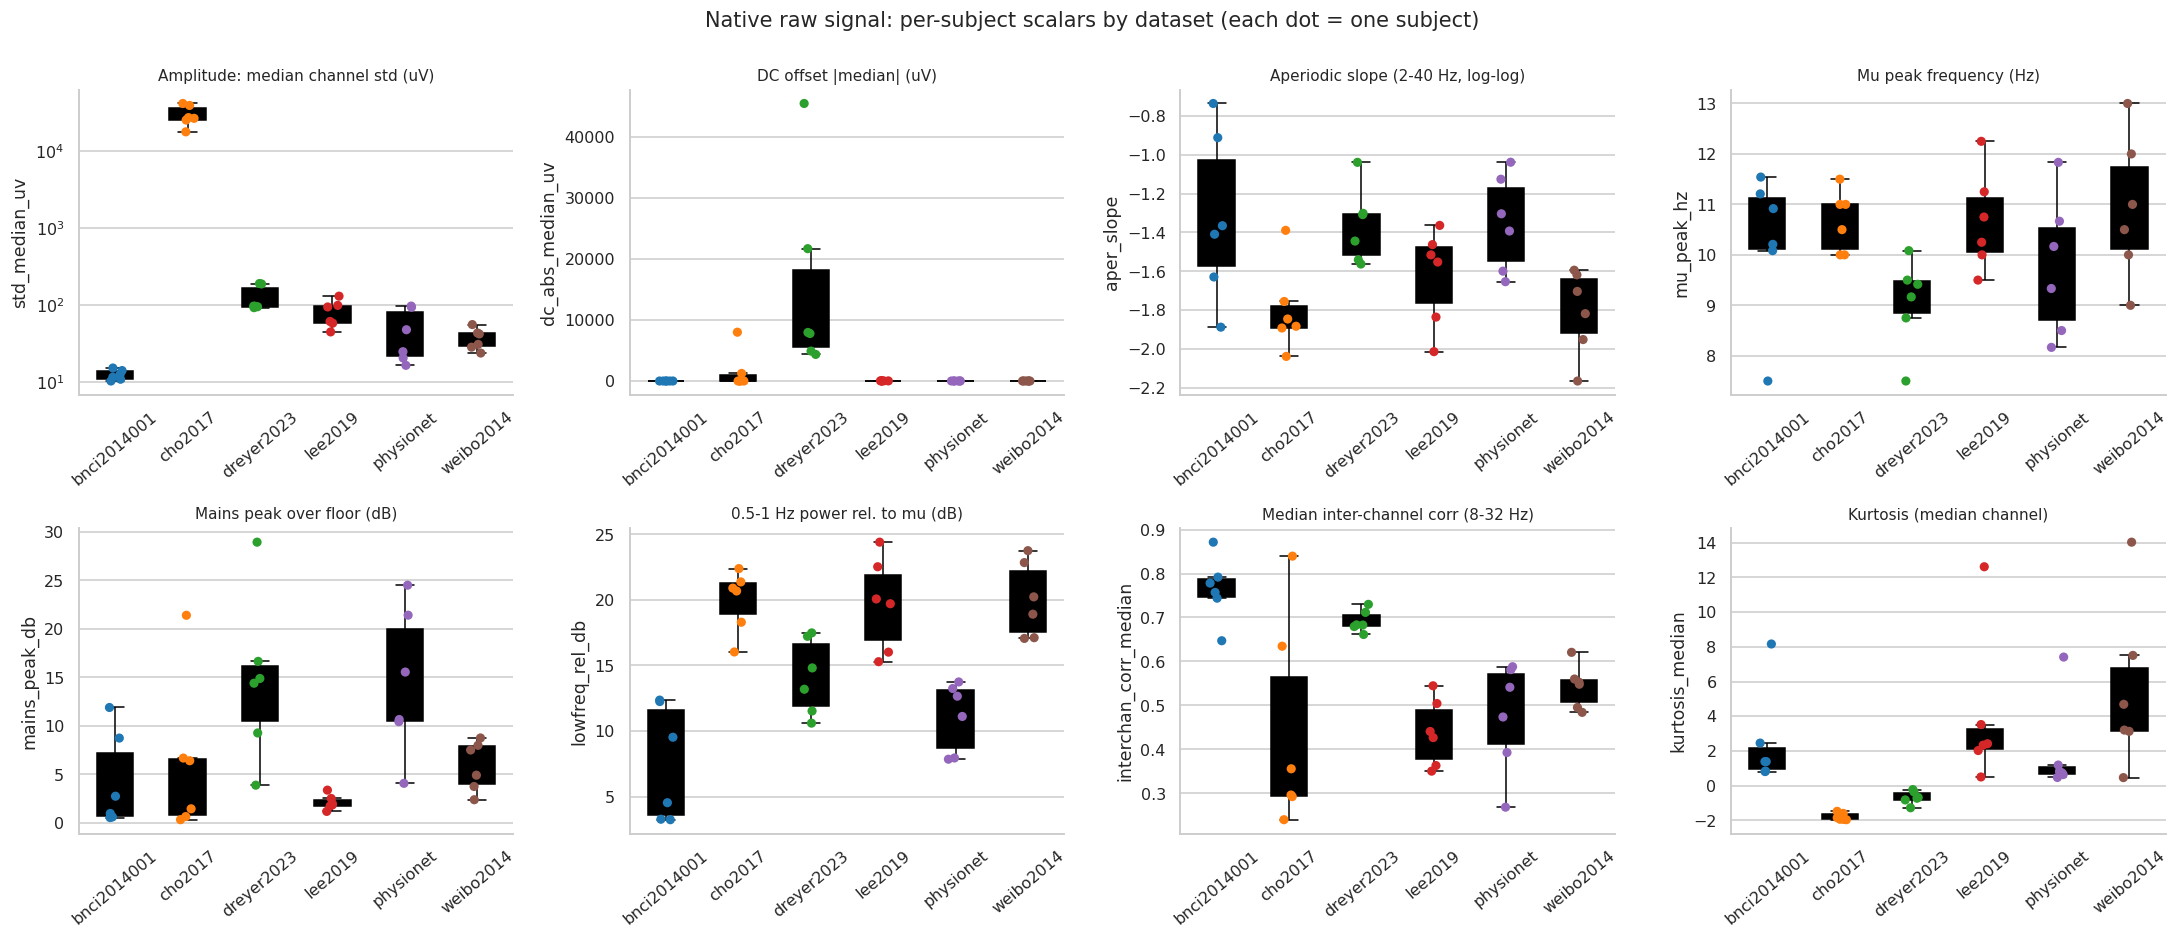

  saved F02b_raw_native_psd.png


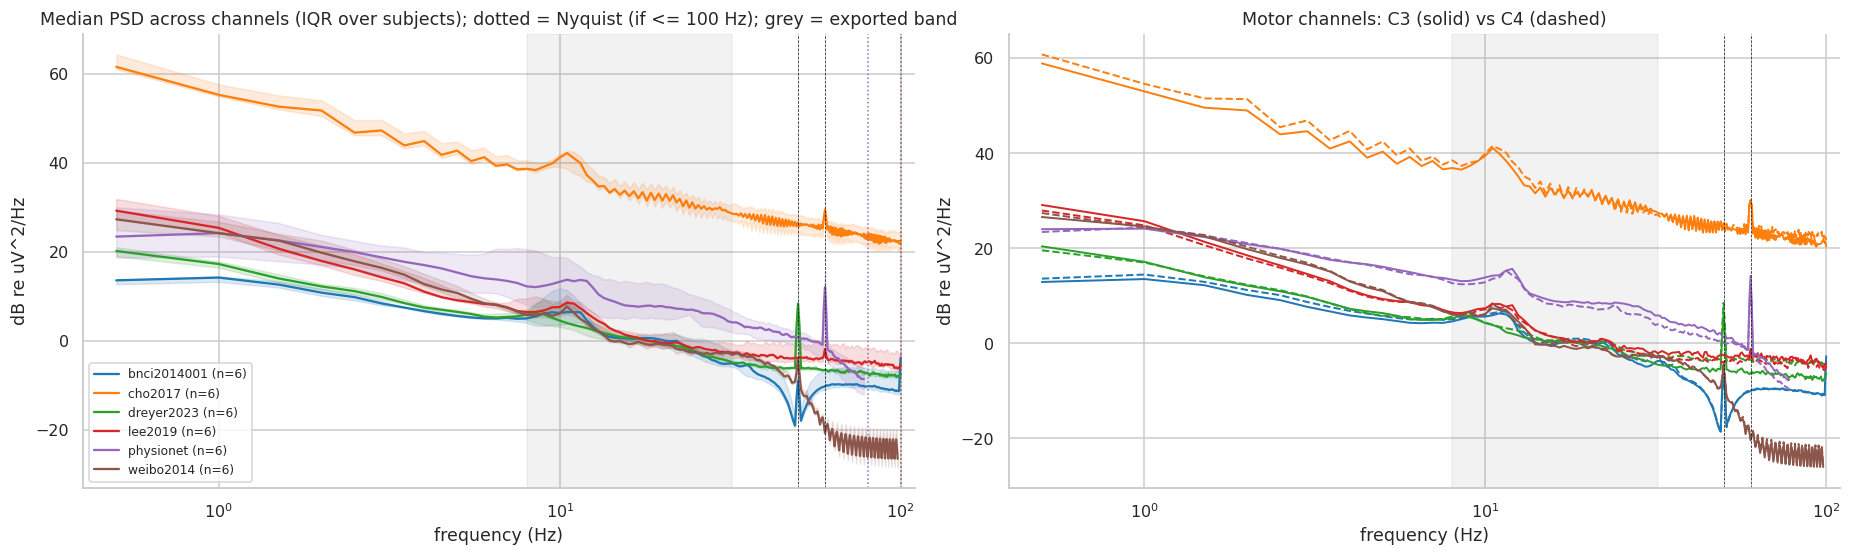

In [12]:
# Raw-domain tables + Figure 2 (skips cleanly if no raw cache)
if len(RAW_DF):
    cols = ["fs", "n_ch", "dc_abs_median_uv", "std_median_uv", "abs_p99_uv", "kurtosis_median", "noisy_channel_frac",
            "flat_channels", "mains_hz", "mains_peak_db", "aper_slope", "aper_offset", "mu_peak_hz", "mu_peak_db",
            "lowfreq_rel_db", "hf_rel_db", "interchan_corr_median", "chanmean_var_frac"]
    raw_tab = RAW_DF.groupby("dataset")[cols].median().round(3)
    display(raw_tab); save_table(raw_tab, "02_raw_native_summary_median")
    save_table(RAW_DF, "02_raw_native_per_subject", index=False)

    fig, axes = plt.subplots(2, 4, figsize=(20, 8.5))
    for ax, (k, ttl) in zip(axes.ravel(), [
            ("std_median_uv", "Amplitude: median channel std (uV)"), ("dc_abs_median_uv", "DC offset |median| (uV)"),
            ("aper_slope", "Aperiodic slope (2-40 Hz, log-log)"), ("mu_peak_hz", "Mu peak frequency (Hz)"),
            ("mains_peak_db", "Mains peak over floor (dB)"), ("lowfreq_rel_db", "0.5-1 Hz power rel. to mu (dB)"),
            ("interchan_corr_median", "Median inter-channel corr (8-32 Hz)"), ("kurtosis_median", "Kurtosis (median channel)")]):
        sns.stripplot(data=RAW_DF, x="dataset", y=k, order=DATASETS, palette=PALETTE, size=6, ax=ax)
        sns.boxplot(data=RAW_DF, x="dataset", y=k, order=DATASETS, color="none", width=.5, fliersize=0, ax=ax)
        ax.set_title(ttl, fontsize=10); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=40)
        if k == "std_median_uv":
            ax.set_yscale("log")
    fig.suptitle("Native raw signal: per-subject scalars by dataset (each dot = one subject)", y=1.0)
    fig.tight_layout(); save_fig(fig, "F02a_raw_native_scalars"); plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(17, 5.2))
    for d in DATASETS:
        m = (RAW_DF["dataset"] == d).to_numpy()
        if not m.any():
            continue
        g = RAW_PSD[m]
        med, lo, hi = np.nanmedian(g, 0), np.nanpercentile(g, 25, 0), np.nanpercentile(g, 75, 0)
        ax[0].plot(RAW_GRID, 10 * med, color=PALETTE[d], label=f"{d} (n={m.sum()})"); ax[0].fill_between(RAW_GRID, 10 * lo, 10 * hi, color=PALETTE[d], alpha=.15)
        ny = RAW_DF.loc[m, "fs"].median() / 2
        if ny <= ACFG.raw_psd_fmax:                                  # Nyquists above the plotted range would only stretch the axis
            ax[0].axvline(ny, color=PALETTE[d], ls=":", lw=1)
        gm = RAW_PSD_MOT[m]
        for kk, ls in ((0, "-"), (1, "--")):
            ax[1].plot(RAW_GRID, 10 * np.nanmedian(gm[:, kk], 0), color=PALETTE[d], ls=ls, lw=1.3)
    for a in ax:
        a.set_xscale("log"); a.set_xlabel("frequency (Hz)"); a.set_xlim(0.4, ACFG.raw_psd_fmax * 1.1)
        a.axvspan(8, 32, color="grey", alpha=.10); a.axvline(50, color="k", lw=.5, ls="--"); a.axvline(60, color="k", lw=.5, ls="--")
    ax[0].set(title="Median PSD across channels (IQR over subjects); dotted = Nyquist (if <= 100 Hz); grey = exported band", ylabel="dB re uV^2/Hz")
    ax[1].set(title="Motor channels: C3 (solid) vs C4 (dashed)", ylabel="dB re uV^2/Hz")
    ax[0].legend(fontsize=8); fig.tight_layout(); save_fig(fig, "F02b_raw_native_psd"); plt.show()
else:
    print("No raw-domain cache: run the raw cells in Colab (or lower raw_subjects_per_dataset). Domain E below does not need it.")

**Reading guide for Domain R.**
- *Nyquist / high-frequency attenuation*: the dotted lines mark each dataset's native Nyquist. A dataset whose spectrum falls well below the others
  above ~40 Hz has a hardware low-pass that the 128 Hz export hides; this does not matter inside 8–32 Hz but matters for any wider band.
- *Mains*: peaks at 50 or 60 Hz should sit far above 32 Hz. A mains ratio that is large **and** an anti-alias-poor dataset is the only case where mains
  could alias into the export band; check it before blaming the model.
- *Aperiodic slope / offset* and *mu-peak frequency*: if datasets separate here, a single fixed spectral template is wrong and per-dataset tilt/peak
  alignment (Section 7) is justified; if they overlap, the 1/f component is not the dataset signature.
- *Low-frequency power, inter-channel correlation, channel-mean variance*: amplifier high-pass and reference differences. They are removed or reduced by the
  8–32 Hz filter and CAR in the export, so they tell you what the pipeline is already absorbing.

## Section 3 — Domain E: per-trial descriptors from the exported shards (one streaming pass, cached)

Every shard is read once; per-trial descriptors are computed on the **shared channels only** and saved per subject
(`cache_E/`), so a crash or a re-run never starts over, and the cache is invalidated automatically if any analysis
setting (bands, Welch parameters, channel set, `preproc_id`) changes.

**Four signal views** are computed from the same trials, because they are the candidate *inductive* ways of removing scale:

| View | Definition | Needs target data? |
|---|---|---|
| `raw` | stored `X` (µV, band-passed, CAR) | no |
| `ztrial` | stored `X_z`: each channel z-scored over time within its trial | no |
| `gscale` | each trial divided by its own global RMS over the shared channels (keeps between-channel power ratios) | no |
| `ea` | Euclidean Alignment on the shared channels: `R^(-1/2) X` with `R` = the subject's mean trial covariance | **yes** — unlabeled trials of the same subject |

**Per-trial descriptors** (shared channels, 9–31 Hz): log10 band power for mu / beta-low / beta-high at each shared channel
(3×S numbers per view); RMS (µV); kurtosis; spectral centroid, entropy, peak frequency, tilt (log-log slope 13–31 Hz); zero-crossing
rate; autocorrelation e-fold time; mean log-PSD of the shared channels and of C3/CZ/C4. **Per-subject**: mean autocorrelation curve,
trace-normalized mean spatial covariance, and class-conditional envelope time courses of C3/CZ/C4 (mu 9–12 Hz, beta 13–30 Hz).

In [13]:
# Feature extraction (pure numpy / scipy)
BANDS_ENV = {"mu": (9.0, 12.0), "beta": (13.0, 30.0)}
ENV_SOS = {b: sps.butter(4, band, btype="band", fs=FS, output="sos") for b, band in BANDS_ENV.items()}
ACF_L = int(round(ACFG.acf_max_lag_sec * FS))
_FREQS_FULL = np.fft.rfftfreq(ACFG.welch_nperseg, 1.0 / FS)
PSD_SEL = (_FREQS_FULL >= PSD_BAND[0] - 1e-9) & (_FREQS_FULL <= PSD_BAND[1] + 1e-9)
PSD_F = _FREQS_FULL[PSD_SEL]                       # 9..31 Hz -> 23 bins
T_ENV = T_AXIS[: (N_SAMPLES // ACFG.env_decim) * ACFG.env_decim].reshape(-1, ACFG.env_decim).mean(1)
VIEWS = ["raw", "ztrial", "gscale", "ea"]
DESC_NAMES = [f"{b}:{c}" for b in BANDS for c in SHARED_NAMES]       # column names of every descriptor matrix

def welch_psd(x):
    f, p = sps.welch(x, fs=FS, nperseg=ACFG.welch_nperseg, noverlap=ACFG.welch_noverlap, window="hann",
                     detrend="constant", axis=-1)
    return f, p

def band_desc(p, f):
    df = f[1] - f[0]; cols = []
    for lo, hi in BANDS.values():
        m = (f >= lo - 1e-9) & (f <= hi + 1e-9)
        cols.append(np.log10(p[..., m].sum(-1) * df + 1e-20))
    return np.concatenate(cols, axis=1).astype(np.float32)           # (n, 3S)

def per_trial_z(X):
    Xc = X - X.mean(-1, keepdims=True)
    return Xc / (Xc.std(-1, keepdims=True) + 1e-6)

def build_views(Xs, Xz_s):
    """Xs: (n,S,T) raw uV on shared channels."""
    Xc = Xs - Xs.mean(-1, keepdims=True)
    g = np.sqrt((Xc ** 2).mean(axis=(1, 2), keepdims=True)) + 1e-12
    C = np.einsum("nst,nut->nsu", Xc, Xc) / Xc.shape[-1]
    R = C.mean(0)
    w, V = np.linalg.eigh(R)
    w = np.maximum(w, max(w.max() * 1e-6, 1e-12))
    W = (V * (1.0 / np.sqrt(w))) @ V.T
    views = {"raw": Xs, "ztrial": Xz_s if Xz_s is not None else per_trial_z(Xs),
             "gscale": Xc / g, "ea": np.einsum("su,nut->nst", W, Xc)}
    return views, R

def acf_trials(Xc):
    T = Xc.shape[-1]
    F = np.fft.rfft(Xc, n=2 * T, axis=-1)
    a = np.fft.irfft(np.abs(F) ** 2, axis=-1)[..., : ACF_L + 1]
    return a / (a[..., :1] + 1e-20)                                  # (n,S,L+1)

def scalar_features(Xs, p_sel):
    """Xs raw shared (n,S,T); p_sel: Welch PSD (n,S,Fb) restricted to PSD_BAND."""
    n = Xs.shape[0]
    Xc = Xs - Xs.mean(-1, keepdims=True)
    ch_rms = np.sqrt((Xc ** 2).mean(-1))
    rms = np.sqrt((ch_rms ** 2).mean(1))
    kurt = np.median(spst.kurtosis(Xc, axis=-1), axis=1)
    pm = p_sel.mean(1)                                               # (n,Fb) linear mean over channels
    q = pm / pm.sum(1, keepdims=True)
    centroid = (q * PSD_F[None]).sum(1)
    entropy = -(q * np.log(q + 1e-20)).sum(1) / np.log(q.shape[1])
    pk_m = (PSD_F >= 9) & (PSD_F <= 14)
    peak = PSD_F[pk_m][np.argmax(pm[:, pk_m], axis=1)]
    t_m = (PSD_F >= 13) & (PSD_F <= 31)
    lf, lp = np.log10(PSD_F[t_m]), np.log10(pm[:, t_m] + 1e-20)
    lf_c = lf - lf.mean()
    tilt = (lp * lf_c[None]).sum(1) / (lf_c ** 2).sum()
    sg = np.signbit(Xc)
    zcr = (np.diff(sg, axis=-1) != 0).sum(-1).mean(1) / (Xc.shape[-1] / FS)
    acf = acf_trials(Xc).mean(1)                                     # (n,L+1) mean over channels
    below = acf < (1.0 / np.e)
    has = below.any(1); k = np.where(has, np.argmax(below, axis=1), ACF_L); k0 = np.maximum(k - 1, 0)
    a0, a1 = acf[np.arange(n), k0], acf[np.arange(n), k]
    frac = np.where((a0 - a1) > 1e-12, (a0 - 1.0 / np.e) / np.maximum(a0 - a1, 1e-12), 0.0)     # linear interpolation: sub-sample resolution
    efold = np.where(has, k0 + np.clip(frac, 0.0, 1.0), ACF_L) / FS * 1000.0
    return pd.DataFrame({"rms_uv": rms, "log_rms": np.log10(rms + 1e-12), "kurtosis": kurt, "centroid_hz": centroid,
                         "entropy": entropy, "peak_hz": peak, "tilt": tilt, "zcr_hz": zcr, "efold_ms": efold}).astype(np.float32), acf

def envelope_trials(xm):
    out = []
    for b in BANDS_ENV:
        y = sps.sosfiltfilt(ENV_SOS[b], xm, axis=-1)
        p = np.abs(sps.hilbert(y, axis=-1)) ** 2
        p = p / (p.mean(axis=(1, 2), keepdims=True) + 1e-20)      # ONE scalar per trial and band (mean over time AND motor channels): preserves C3/C4 ratios
        n, c, T = p.shape; D = ACFG.env_decim
        out.append(p[..., : (T // D) * D].reshape(n, c, T // D, D).mean(-1))
    return np.stack(out, axis=1)                                     # (n, 2 bands, 3, T')

def class_mean_env(env, y):
    out = np.full((env.shape[1], 2, env.shape[2], env.shape[3]), np.nan, dtype=np.float32)
    for c in (0, 1):
        m = (y == c)
        if m.any():
            out[:, c] = env[m].mean(0)
    return out                                                       # (2 bands, 2 classes, 3, T')

def e_cache_sig():
    payload = [ACFG.cache_version, ACFG.welch_nperseg, ACFG.welch_noverlap, PSD_BAND, BANDS, BANDS_ENV, ACF_L,
               ACFG.env_decim, ACFG.max_trials_per_subject, SHARED_NAMES, layout.get("preproc_id"), N_SAMPLES]
    return hashlib.sha1(json.dumps(payload, sort_keys=True, default=str).encode()).hexdigest()[:10]
print(f"descriptor columns: {len(DESC_NAMES)} (3 bands x {S} shared channels) | PSD bins: {len(PSD_F)} ({PSD_F[0]:.0f}-{PSD_F[-1]:.0f} Hz) "
      f"| ACF lags: {ACF_L+1} | envelope points: {len(T_ENV)}")

descriptor columns: 54 (3 bands x 18 shared channels) | PSD bins: 23 (9-31 Hz) | ACF lags: 65 | envelope points: 48


In [14]:
# One subject -> one cache file
def process_subject(row, sig, first_check=False):
    z = np.load(EXPORT_ROOT / row["shard_path"], allow_pickle=True)
    if first_check:
        names = [str(c) for c in z["channel_names"]]
        assert names == list(TARGET_CHANNELS), "shard channel order differs from channels/target_channels.json"
    X = z["X"][:, SHARED_IDX, :].astype(np.float64)
    Xz = z["X_z"][:, SHARED_IDX, :].astype(np.float64) if "X_z" in z.files else None
    y = z["y"].astype(np.int8); run = np.array([str(r) for r in z["run_label"]])
    n = len(y)
    if ACFG.max_trials_per_subject and n > ACFG.max_trials_per_subject:
        sel = np.sort(np.random.default_rng(ACFG.seed + int(row["global_subject_idx"])).choice(n, ACFG.max_trials_per_subject, replace=False))
        X, Xz, y, run = X[sel], (Xz[sel] if Xz is not None else None), y[sel], run[sel]
    assert X.shape[-1] == N_SAMPLES, f"{row['subject_key']}: {X.shape[-1]} samples != {N_SAMPLES}"
    fb = np.array([dreyer_feedback_rule(row["dataset"], r) for r in run])

    views, R = build_views(X, Xz)
    out = {"sig": sig, "y": y, "run_label": run, "fb": fb}
    for v in VIEWS:
        f, p = welch_psd(views[v])
        out[f"desc_{v}"] = band_desc(p[..., PSD_SEL], f[PSD_SEL])
        if v == "raw":
            p_sel = p[..., PSD_SEL]
            sc, acf = scalar_features(views["raw"], p_sel)
            for c in sc.columns:
                out[f"sc_{c}"] = sc[c].to_numpy()
            out["acf_mean"] = acf.mean(0).astype(np.float32)
            out["psd_shared"] = np.log10(p_sel.mean(1) + 1e-20).astype(np.float32)               # (n,Fb)
            out["psd_motor"] = np.log10(p_sel[:, MOTOR_SH] + 1e-20).astype(np.float32)           # (n,3,Fb)
    out["cov"] = (R / np.trace(R) * R.shape[0]).astype(np.float32)
    env = envelope_trials(X[:, MOTOR_SH, :])
    out["env_all"] = class_mean_env(env, y)
    nan = np.full_like(out["env_all"], np.nan)
    if row["dataset"] == "dreyer2023" and fb.any() and (~fb).any():
        out["env_acq"], out["env_fb"] = class_mean_env(env[~fb], y[~fb]), class_mean_env(env[fb], y[fb])
    else:
        out["env_acq"], out["env_fb"] = nan, nan
    return out

def run_E(rows=None):
    sig, t0, done = e_cache_sig(), time.time(), 0
    rows = SUBJ if rows is None else rows
    for i, row in rows.iterrows():
        cpath = CACHE_E / f"{row['dataset']}_{int(row['subject_id']):03d}.npz"
        if cpath.exists():
            try:
                if str(np.load(cpath, allow_pickle=True)["sig"]) == sig:
                    continue
            except Exception:
                pass
        res = process_subject(row, sig, first_check=(done == 0))
        np.savez_compressed(cpath, **res)
        done += 1
        if done % 10 == 0 or done == 1:
            print(f"  [{i+1}/{len(rows)}] {row['subject_key']:<16s} computed={done}  ({time.time()-t0:.0f}s)")
    print(f"domain E pass finished: {done} subject(s) computed, rest were cached ({time.time()-t0:.0f}s)")

run_E()

  [1/268] bnci2014001:1    computed=1  (5s)
  [10/268] cho2017:2        computed=10  (38s)
  [20/268] cho2017:12       computed=20  (70s)
  [30/268] cho2017:24       computed=30  (102s)
  [40/268] cho2017:36       computed=40  (134s)
  [50/268] cho2017:49       computed=50  (166s)
  [60/268] dreyer2023:8     computed=60  (193s)
  [70/268] dreyer2023:18    computed=70  (219s)
  [80/268] dreyer2023:29    computed=80  (244s)
  [90/268] dreyer2023:42    computed=90  (273s)
  [100/268] dreyer2023:53    computed=100  (299s)
  [110/268] dreyer2023:67    computed=110  (325s)
  [120/268] dreyer2023:80    computed=120  (351s)
  [130/268] lee2019:5        computed=130  (386s)
  [140/268] lee2019:15       computed=140  (412s)
  [150/268] lee2019:28       computed=150  (439s)
  [160/268] lee2019:39       computed=160  (469s)
  [170/268] lee2019:53       computed=170  (497s)
  [180/268] physionet:9      computed=180  (514s)
  [190/268] physionet:22     computed=190  (531s)
  [200/268] physionet:37  

In [15]:
# Aggregate all caches into analysis arrays
def load_E():
    sig = e_cache_sig(); metas, descs, scs, psd_s, psd_m = [], {v: [] for v in VIEWS}, [], [], []
    sub_rows, acf, cov, env_all, env_acq, env_fb = [], [], [], [], [], []
    for _, r in SUBJ.iterrows():
        z = np.load(CACHE_E / f"{r['dataset']}_{int(r['subject_id']):03d}.npz", allow_pickle=True)
        assert str(z["sig"]) == sig, f"stale cache for {r['subject_key']}"
        n = len(z["y"])
        metas.append(pd.DataFrame({"dataset": r["dataset"], "subject_id": int(r["subject_id"]), "subject_key": r["subject_key"],
                                   "y": z["y"], "run_label": z["run_label"], "fb": z["fb"]}))
        for v in VIEWS:
            descs[v].append(z[f"desc_{v}"])
        scs.append(pd.DataFrame({c[3:]: z[c] for c in z.files if c.startswith("sc_")}))
        psd_s.append(z["psd_shared"]); psd_m.append(z["psd_motor"])
        sub_rows.append({"dataset": r["dataset"], "subject_id": int(r["subject_id"]), "subject_key": r["subject_key"], "n": n})
        acf.append(z["acf_mean"]); cov.append(z["cov"]); env_all.append(z["env_all"]); env_acq.append(z["env_acq"]); env_fb.append(z["env_fb"])
    META = pd.concat(metas, ignore_index=True)
    SC = pd.concat(scs, ignore_index=True)
    return dict(META=META, SC=SC, DESC={v: np.concatenate(descs[v]) for v in VIEWS}, PSD_SH=np.concatenate(psd_s),
                PSD_MOT=np.concatenate(psd_m), SUBJ_E=pd.DataFrame(sub_rows), ACF=np.array(acf), COV=np.array(cov),
                ENV=np.array(env_all), ENV_ACQ=np.array(env_acq), ENV_FB=np.array(env_fb))

E = load_E()
META, SC, DESC, PSD_SH, PSD_MOT = E["META"], E["SC"], E["DESC"], E["PSD_SH"], E["PSD_MOT"]
SUBJ_E, ACF, COV, ENV, ENV_ACQ, ENV_FB = E["SUBJ_E"], E["ACF"], E["COV"], E["ENV"], E["ENV_ACQ"], E["ENV_FB"]
DS_CODE = META["dataset"].map({d: i for i, d in enumerate(DATASETS)}).to_numpy()
assert len(META) == len(SC) == len(PSD_SH) == len(DESC["raw"]) and all(np.isfinite(DESC[v]).all() for v in VIEWS), "non-finite descriptors"

# band powers averaged over shared channels (log10 of mean linear power would need re-computation; the mean of log10 is used consistently)
for b in BANDS:
    idx = [i for i, n in enumerate(DESC_NAMES) if n.startswith(b + ":")]
    SC[f"logP_{b}"] = DESC["raw"][:, idx].mean(1)
SC["mu_over_beta"] = SC["logP_mu"] - 0.5 * (SC["logP_beta_low"] + SC["logP_beta_high"])
print(f"{len(META)} trials | {META['subject_key'].nunique()} subjects | descriptor views: {list(DESC)} x {DESC['raw'].shape[1]} dims")
print("shared-channel RMS (uV) median by dataset:"); print(SC.groupby(META["dataset"])["rms_uv"].median().round(2).to_string())

43207 trials | 268 subjects | descriptor views: ['raw', 'ztrial', 'gscale', 'ea'] x 54 dims
shared-channel RMS (uV) median by dataset:
dataset
bnci2014001     2.320000
cho2017        73.830002
dreyer2023      2.620000
lee2019         2.470000
physionet       7.540000
weibo2014       2.900000


## Section 4 — Distributions across datasets (exported domain)

**Unit of analysis.** The subject, not the trial. Distribution plots show **subject medians** (one dot per subject) so a dataset with many trials per
subject cannot look more certain than it is; tests use subject medians; trial-level violins appear only where the trial distribution itself is the point.
Everything below reads from the cached arrays, so it is cheap to re-run.

In [16]:
# Helpers shared by the analysis cells
_OFF = np.concatenate([[0], np.cumsum(SUBJ_E["n"].to_numpy())])
SUBJ_DS = SUBJ_E["dataset"].to_numpy()

def per_subject(arr, fn=np.mean):
    """Reduce trial-aligned array (N, ...) to (n_subjects, ...) in SUBJ_E order."""
    return np.array([fn(arr[_OFF[i]:_OFF[i + 1]], axis=0) for i in range(len(SUBJ_E))])

def subj_table(cols):
    """Subject-median table of scalar descriptors."""
    df = pd.concat([META[["dataset", "subject_key"]], SC[cols]], axis=1)
    return df.groupby(["dataset", "subject_key"], sort=False)[cols].median().reset_index()

def kw_report(cols):
    sm, rows = subj_table(cols), []
    for c in cols:
        groups = [g[c].to_numpy() for _, g in sm.groupby("dataset")]
        n, k = len(sm), len(groups)
        if np.ptp(sm[c].to_numpy()) == 0:
            rows.append({"feature": c, "H": np.nan, "p": np.nan, "epsilon2": np.nan}); continue
        H, p = spst.kruskal(*groups)
        rows.append({"feature": c, "H": H, "p": p, "epsilon2": (H - k + 1) / (n - k)})
    return pd.DataFrame(rows).set_index("feature")

def strip_box(ax, sm, col, title=None, log=False):
    sns.stripplot(data=sm, x="dataset", y=col, order=DATASETS, palette=PALETTE, size=3.8, alpha=.75, ax=ax)
    sns.boxplot(data=sm, x="dataset", y=col, order=DATASETS, color="none", width=.55, fliersize=0, ax=ax)
    ax.set(xlabel="", title=title or col); ax.tick_params(axis="x", rotation=40)
    if log: ax.set_yscale("log")

def band_shade(ax):
    ax.axvspan(PSD_F[0] - 1, PSD_BAND[0], color="grey", alpha=.15); ax.axvspan(PSD_BAND[1], PSD_F[-1] + 1, color="grey", alpha=.15)
    for lo, hi in BANDS.values():
        ax.axvline(lo, color="k", lw=.4, ls=":"); ax.axvline(hi, color="k", lw=.4, ls=":")

### 4.1 Amplitude

  saved F03_amplitude.png


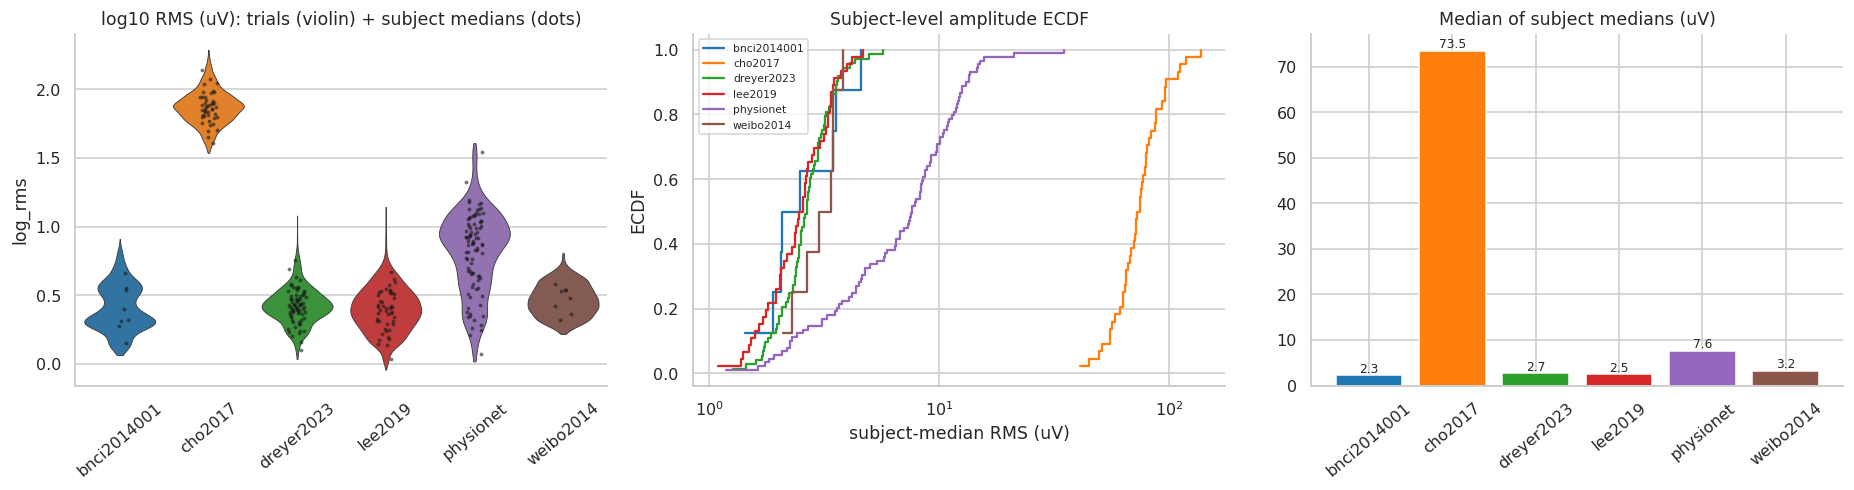

,H,p,epsilon2
feature,,,
log_rms,174.0253,0.0,0.6451


  saved 03_amplitude_kruskal.csv
between-dataset spread of median log10 RMS: 1.51 decades (32.4x) | mean within-dataset subject SD: 0.15 decades


In [17]:
# Figure 3: amplitude (RMS over shared channels, uV, after 8-32 Hz band-pass and CAR)
AMP_COLS = ["log_rms"]
sm_amp = subj_table(["rms_uv", "log_rms"])
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
_tmp = META.assign(log_rms=SC["log_rms"])
samp = pd.concat([g.sample(min(len(g), 2500), random_state=0) for _, g in _tmp.groupby("dataset")])
sns.violinplot(data=samp, x="dataset", y="log_rms", order=DATASETS, palette=PALETTE, inner=None, cut=0, linewidth=.6, ax=ax[0])
sns.stripplot(data=sm_amp, x="dataset", y="log_rms", order=DATASETS, color="k", size=2.5, alpha=.6, ax=ax[0])
ax[0].set(title="log10 RMS (uV): trials (violin) + subject medians (dots)", xlabel=""); ax[0].tick_params(axis="x", rotation=40)
for d in DATASETS:
    v = np.sort(sm_amp.loc[sm_amp["dataset"] == d, "rms_uv"].to_numpy())
    ax[1].step(v, np.arange(1, len(v) + 1) / len(v), color=PALETTE[d], label=d, where="post")
ax[1].set(xscale="log", xlabel="subject-median RMS (uV)", ylabel="ECDF", title="Subject-level amplitude ECDF"); ax[1].legend(fontsize=7)
lvl = sm_amp.groupby("dataset")["rms_uv"].median()
ax[2].bar(range(len(DATASETS)), [lvl[d] for d in DATASETS], color=[PALETTE[d] for d in DATASETS])
ax[2].set_xticks(range(len(DATASETS))); ax[2].set_xticklabels(DATASETS, rotation=40); ax[2].set(title="Median of subject medians (uV)")
for i, d in enumerate(DATASETS):
    ax[2].text(i, lvl[d], f"{lvl[d]:.1f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout(); save_fig(fig, "F03_amplitude"); plt.show()
amp_kw = kw_report(["log_rms"]); display(amp_kw.round(4)); save_table(amp_kw, "03_amplitude_kruskal")
spread = (sm_amp.groupby("dataset")["log_rms"].agg(["median", "std"]))
print(f"between-dataset spread of median log10 RMS: {spread['median'].max()-spread['median'].min():.2f} decades "
      f"({10**(spread['median'].max()-spread['median'].min()):.1f}x) | mean within-dataset subject SD: {spread['std'].mean():.2f} decades")

**Reading guide.** `epsilon2` (Kruskal–Wallis effect size on subject medians) near 0 means amplitude does not separate datasets; above ~0.14 is a large effect.
If amplitude separates datasets strongly while the within-dataset subject SD is similar in size, a per-trial scale normalization is doing real work;
if the within-dataset subject SD is as large as the between-dataset gap, amplitude is mostly a *subject* property and dataset-level gain matching will not help much.

### 4.2 Spectrum (9–31 Hz)

  saved F04_psd.png


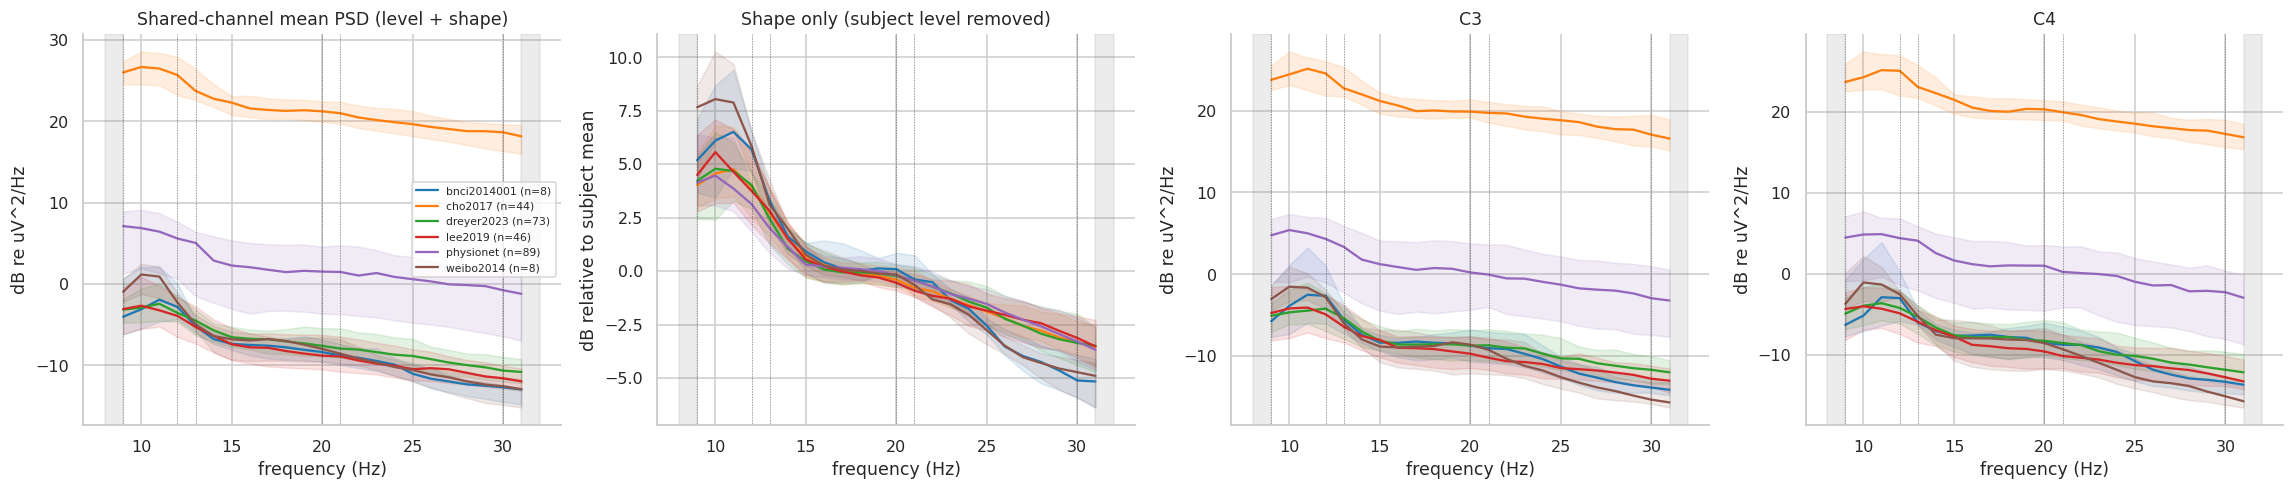

,median_level_dB,level_vs_pooled_dB,shape_rmse_vs_pooled_dB
bnci2014001,-8.83,-1.33,0.99
cho2017,21.59,29.09,0.17
dreyer2023,-7.12,0.38,0.18
lee2019,-8.16,-0.66,0.22
physionet,2.02,9.52,0.39
weibo2014,-7.88,-0.38,1.41


  saved 04_psd_level_vs_shape.csv


In [18]:
# Figure 4: PSD of the shared channels and of C3 / C4. Curves = median over subjects of the subject-mean log-PSD; band = IQR over subjects.
psd_sub = per_subject(PSD_SH)                         # (nsub, Fb) log10 uV^2/Hz
psd_mot_sub = per_subject(PSD_MOT)                    # (nsub, 3, Fb)
shape_sub = psd_sub - psd_sub.mean(1, keepdims=True)  # shape only (level removed per subject)

def psd_panel(ax, arr, title, ylabel, scale=10.0):
    for d in DATASETS:
        a = arr[SUBJ_DS == d] * scale
        med, lo, hi = np.median(a, 0), np.percentile(a, 25, 0), np.percentile(a, 75, 0)
        ax.plot(PSD_F, med, color=PALETTE[d], label=f"{d} (n={len(a)})"); ax.fill_between(PSD_F, lo, hi, color=PALETTE[d], alpha=.13)
    band_shade(ax); ax.set(title=title, xlabel="frequency (Hz)", ylabel=ylabel)

fig, ax = plt.subplots(1, 4, figsize=(21, 4.6))
psd_panel(ax[0], psd_sub, "Shared-channel mean PSD (level + shape)", "dB re uV^2/Hz")
psd_panel(ax[1], shape_sub, "Shape only (subject level removed)", "dB relative to subject mean")
psd_panel(ax[2], psd_mot_sub[:, 0], "C3", "dB re uV^2/Hz"); psd_panel(ax[3], psd_mot_sub[:, 2], "C4", "dB re uV^2/Hz")
ax[0].legend(fontsize=7); fig.tight_layout(); save_fig(fig, "F04_psd"); plt.show()

# how much of the PSD difference is level vs shape?  (subject-level distances to the pooled dataset-median curve)
lvl_gap = pd.Series({d: np.median(psd_sub[SUBJ_DS == d].mean(1)) for d in DATASETS})
shp = {d: np.median(shape_sub[SUBJ_DS == d], 0) for d in DATASETS}
shp_ref = np.median(np.array(list(shp.values())), 0)
shape_gap = pd.Series({d: float(np.sqrt(np.mean((10 * (shp[d] - shp_ref)) ** 2))) for d in DATASETS})
gap_tab = pd.DataFrame({"median_level_dB": (10 * lvl_gap).round(2), "level_vs_pooled_dB": (10 * (lvl_gap - lvl_gap.median())).round(2),
                        "shape_rmse_vs_pooled_dB": shape_gap.round(2)})
display(gap_tab); save_table(gap_tab, "04_psd_level_vs_shape")

**Reading guide.** Panel 1 vs 2 separates *gain* (vertical offsets) from *spectral shape*. Large offsets with similar shape → a scalar gain per trial/subject/dataset is enough.
Different shape (tilt, mu-peak position or height) → gain matching is insufficient and a spectral transform (Section 7) is needed. `shape_rmse_vs_pooled_dB` is the RMS
difference of a dataset's median shape from the pooled median shape; compare it with the IQR width in panel 2 to see whether shape differences exceed subject variability.

  saved F05_band_and_spectral_scalars.png


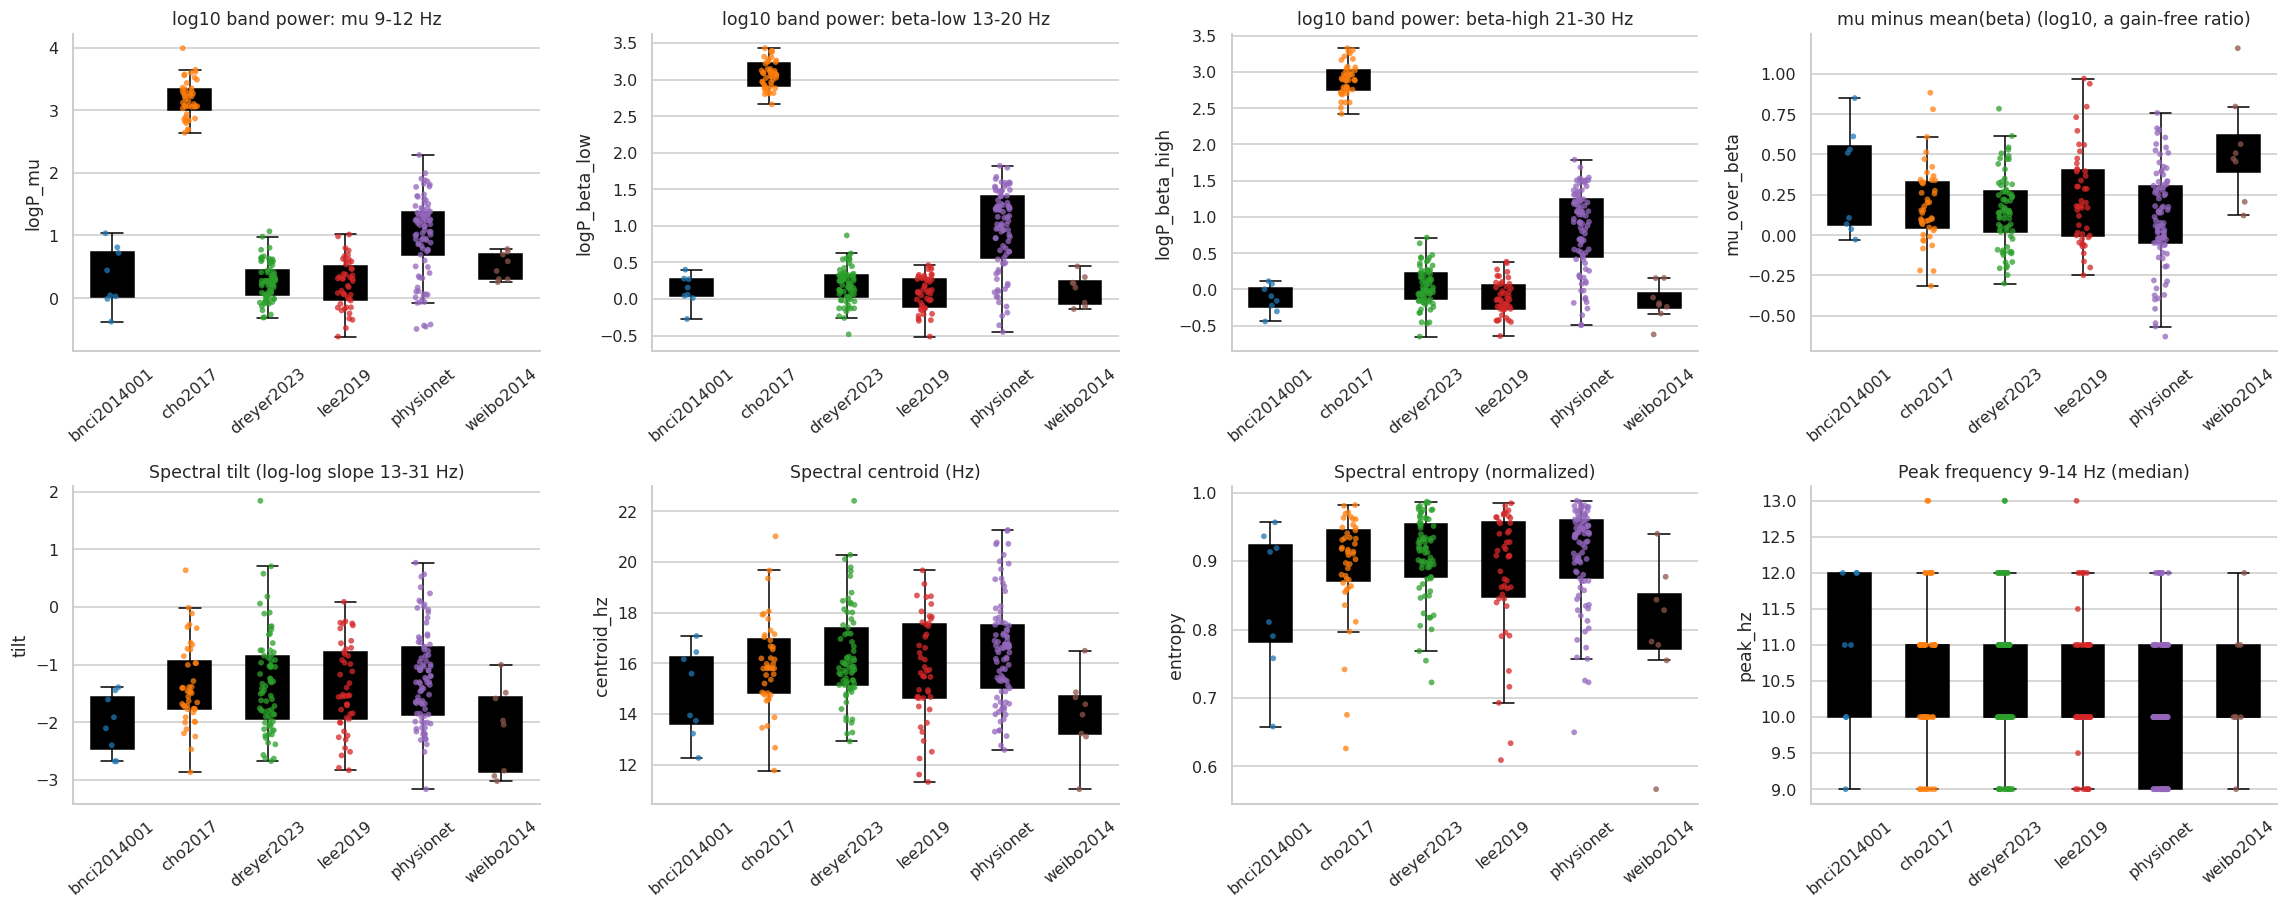

,H,p,epsilon2
feature,,,
logP_mu,160.5562,0.0000,0.5937
logP_beta_low,174.7957,0.0000,0.6481
logP_beta_high,183.9726,0.0000,0.6831
mu_over_beta,16.4366,0.0057,0.0437
tilt,13.7021,0.0176,0.0332
centroid_hz,15.8987,0.0071,0.0416
entropy,15.7870,0.0075,0.0412
peak_hz,11.0391,0.0506,0.0230


  saved 05_spectral_kruskal.csv
  saved F05b_peak_frequency_share.png


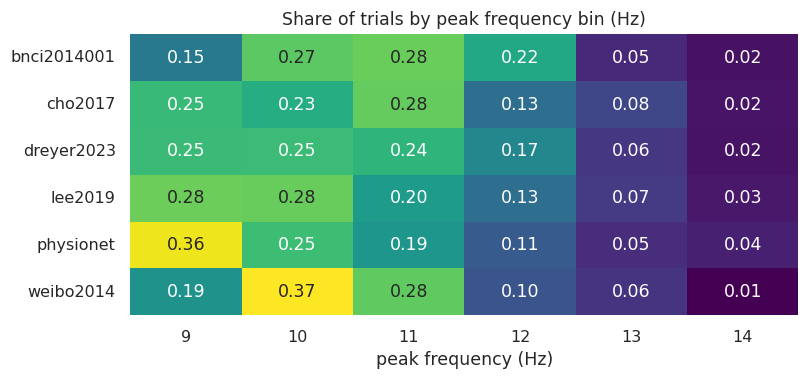

In [19]:
# Figure 5: band power, peak frequency, tilt, centroid, entropy -- subject medians
feat5 = ["logP_mu", "logP_beta_low", "logP_beta_high", "mu_over_beta", "tilt", "centroid_hz", "entropy", "peak_hz"]
sm5 = subj_table(feat5)
titles = {"logP_mu": "log10 band power: mu 9-12 Hz", "logP_beta_low": "log10 band power: beta-low 13-20 Hz",
          "logP_beta_high": "log10 band power: beta-high 21-30 Hz", "mu_over_beta": "mu minus mean(beta) (log10, a gain-free ratio)",
          "tilt": "Spectral tilt (log-log slope 13-31 Hz)", "centroid_hz": "Spectral centroid (Hz)", "entropy": "Spectral entropy (normalized)",
          "peak_hz": "Peak frequency 9-14 Hz (median)"}
fig, axes = plt.subplots(2, 4, figsize=(21, 8.4))
for ax, c in zip(axes.ravel(), feat5):
    strip_box(ax, sm5, c, titles[c])
fig.tight_layout(); save_fig(fig, "F05_band_and_spectral_scalars"); plt.show()
kw5 = kw_report(feat5); display(kw5.round(4)); save_table(kw5, "05_spectral_kruskal")

pk = META[["dataset"]].assign(peak=SC["peak_hz"].round().astype(int))
pk_tab = pk.groupby("dataset")["peak"].value_counts(normalize=True).unstack(fill_value=0).reindex(DATASETS)
fig, ax = plt.subplots(figsize=(7.5, 3.6)); sns.heatmap(pk_tab, annot=True, fmt=".2f", cmap="viridis", cbar=False, ax=ax)
ax.set(title="Share of trials by peak frequency bin (Hz)", xlabel="peak frequency (Hz)", ylabel=""); fig.tight_layout()
save_fig(fig, "F05b_peak_frequency_share"); plt.show()

**Reading guide.** `mu_over_beta` is unaffected by overall gain, so if it still separates datasets the difference is spectral (e.g. stronger mu relative to beta in one cohort), not scale.
The peak-frequency resolution is 1 Hz (1 s Welch windows on 3 s trials), so treat the heatmap as coarse; the raw-domain mu-peak (Section 2, 0.5 Hz resolution on minutes of data) is the sharper measurement.

### 4.3 Temporal structure and signal periods

  saved F06_temporal_structure.png


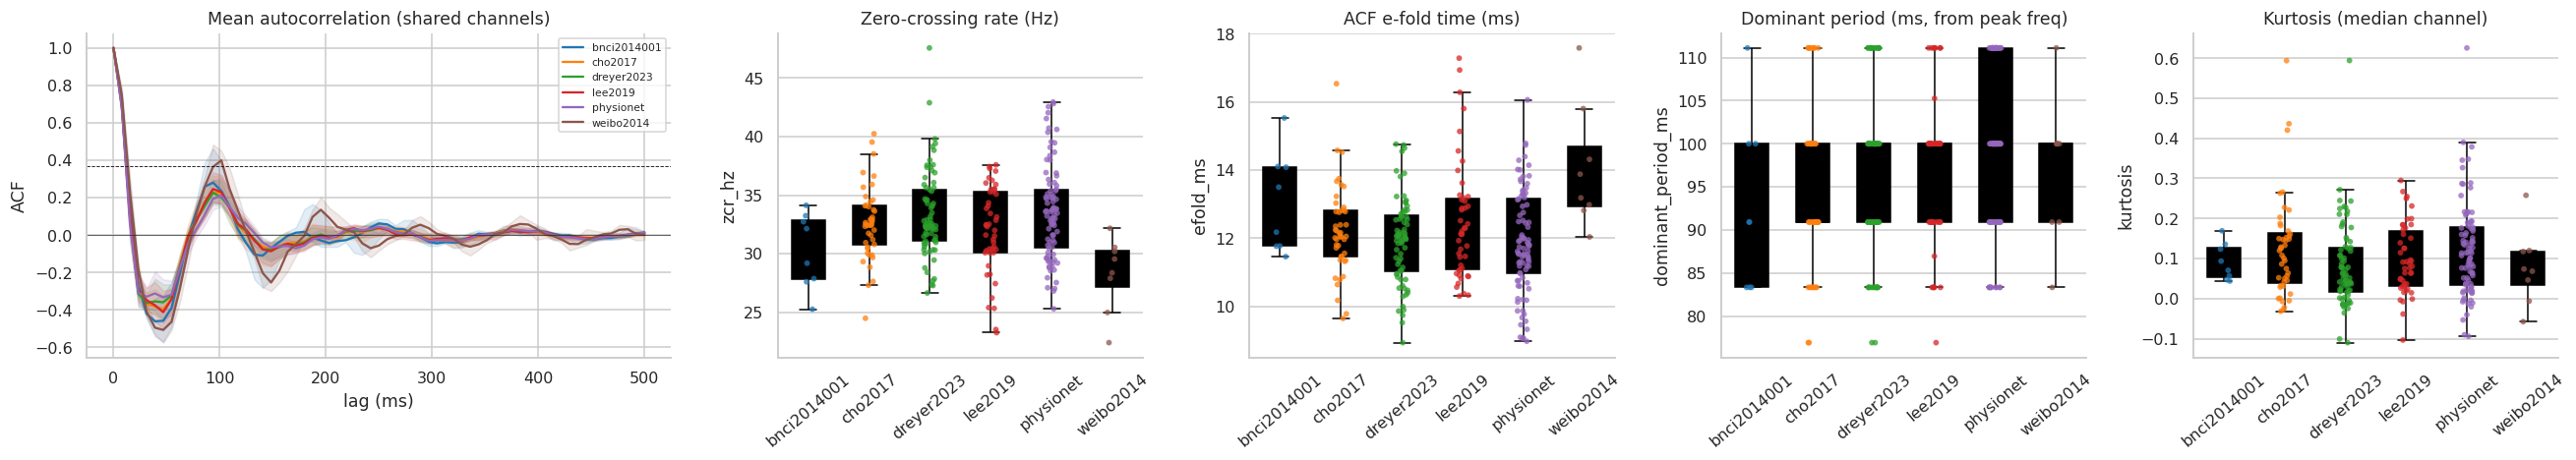

,H,p,epsilon2
feature,,,
zcr_hz,17.3857,0.0038,0.0473
efold_ms,16.1969,0.0063,0.0427
kurtosis,7.9738,0.1577,0.0114


  saved 06_temporal_kruskal.csv


In [20]:
# Figure 6: autocorrelation, zero-crossing rate, e-fold time, dominant period
sm6 = subj_table(["zcr_hz", "efold_ms", "kurtosis", "peak_hz"]); sm6["dominant_period_ms"] = 1000.0 / sm6["peak_hz"]
lags_ms = np.arange(ACF_L + 1) / FS * 1000
fig, ax = plt.subplots(1, 5, figsize=(24, 4.4), gridspec_kw={"width_ratios": [1.6, 1, 1, 1, 1]})
for d in DATASETS:
    a = ACF[SUBJ_DS == d]
    ax[0].plot(lags_ms, np.median(a, 0), color=PALETTE[d], label=d); ax[0].fill_between(lags_ms, np.percentile(a, 25, 0), np.percentile(a, 75, 0), color=PALETTE[d], alpha=.13)
ax[0].axhline(1 / np.e, color="k", lw=.6, ls="--"); ax[0].axhline(0, color="k", lw=.4)
ax[0].set(title="Mean autocorrelation (shared channels)", xlabel="lag (ms)", ylabel="ACF"); ax[0].legend(fontsize=7)
for a_, c, t in zip(ax[1:], ["zcr_hz", "efold_ms", "dominant_period_ms", "kurtosis"],
                    ["Zero-crossing rate (Hz)", "ACF e-fold time (ms)", "Dominant period (ms, from peak freq)", "Kurtosis (median channel)"]):
    strip_box(a_, sm6, c, t)
fig.tight_layout(); save_fig(fig, "F06_temporal_structure"); plt.show()
kw6 = kw_report(["zcr_hz", "efold_ms", "kurtosis"]); display(kw6.round(4)); save_table(kw6, "06_temporal_kruskal")

**Reading guide.** After an 8–32 Hz band-pass the zero-crossing rate and autocorrelation decay are controlled mostly by *where the spectral mass sits inside the band*, so they are a
second, time-domain view of the spectral-shape differences above. A dataset with higher kurtosis has heavier-tailed (more transient/artifact-like) amplitude statistics, which matters for
any scale-sensitive loss or normalization that assumes Gaussian-like trials.

### 4.4 Task signal: lateralization over time, and does it point the same way in every dataset?

For each subject and class, the band envelope at C3 and C4 (normalized by one common scalar per trial and band, so their ratio is kept) is averaged over trials, and the lateralization index is
`LI(t) = (P_C4 - P_C3) / (P_C4 + P_C3)`. Right-hand imagery should depress C3 (so LI > 0), left-hand imagery should depress C4 (LI < 0),
therefore `ΔLI = LI_right − LI_left` should be **positive**. A dataset with negative ΔLI would indicate a label or hemisphere mapping problem, not a weak signal.
Edges of the envelope are trimmed by `env_trim_sec` because the narrow-band filter has start-up transients.

  saved F07a_lateralization_timecourses.png


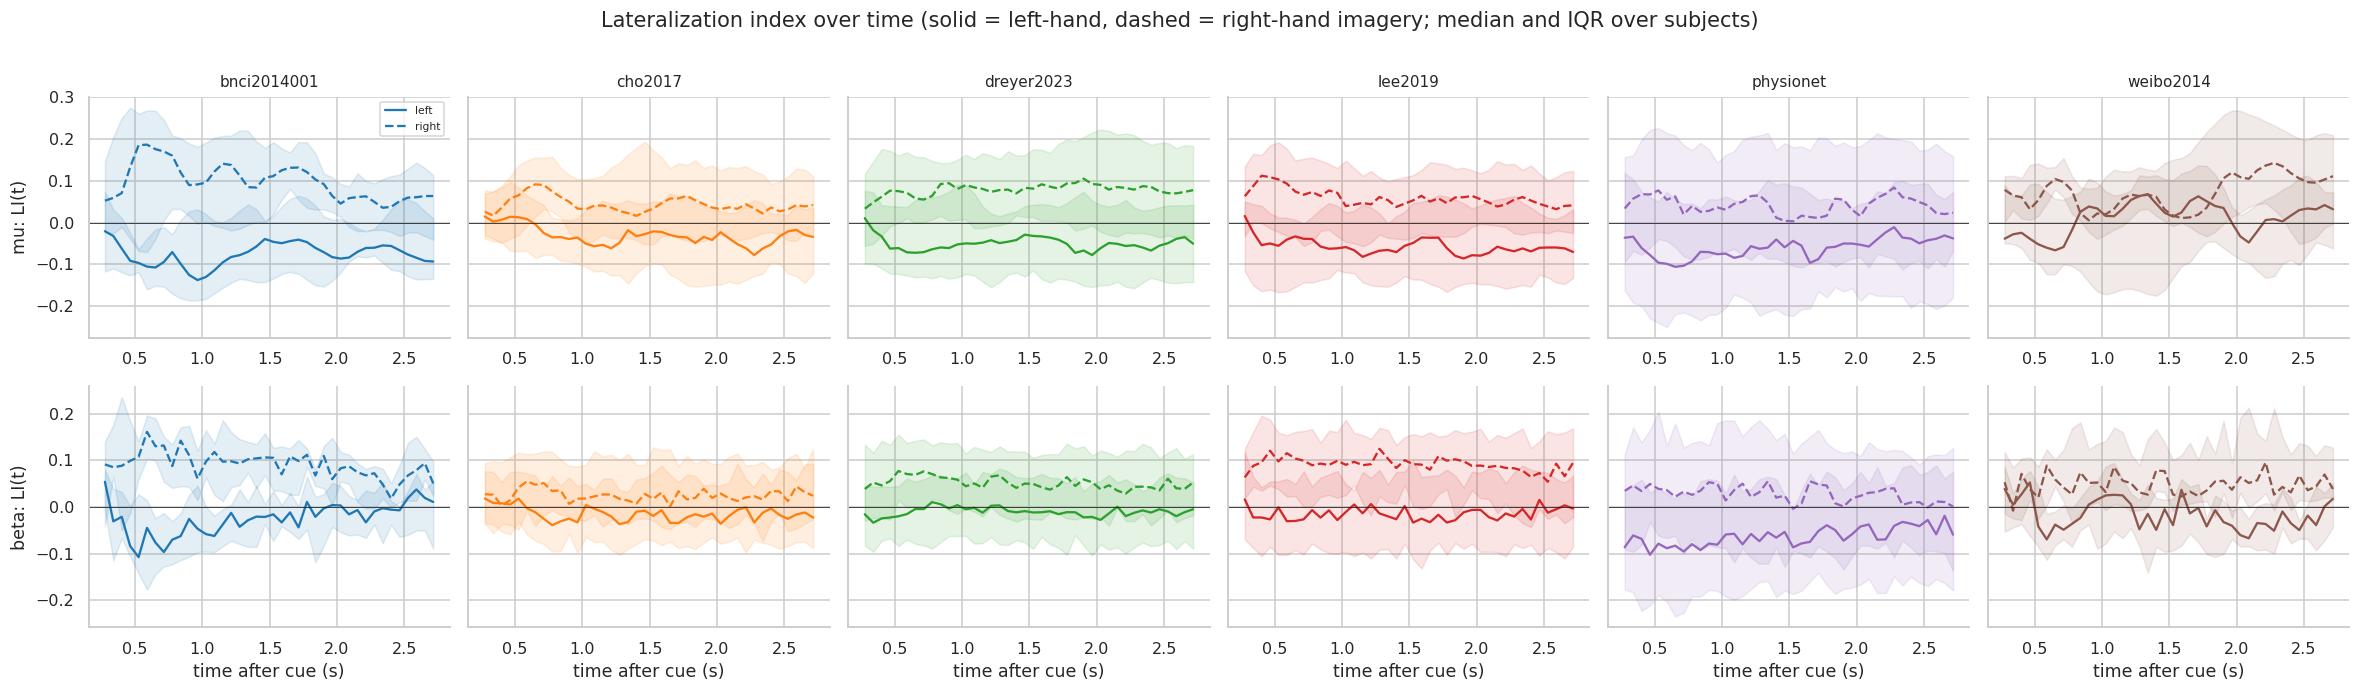

In [21]:
# Figure 7a: LI(t) by dataset / band / class
C3_, CZ_, C4_ = 0, 1, 2
def li_curves(env):                      # env: (nsub, 2 bands, 2 classes, 3 chans, T') -> (nsub, 2, 2, T')
    return (env[:, :, :, C4_] - env[:, :, :, C3_]) / (env[:, :, :, C4_] + env[:, :, :, C3_] + 1e-12)
LI = li_curves(ENV)
tmask = (T_ENV >= MASTER_WINDOW[0] + ACFG.env_trim_sec) & (T_ENV <= MASTER_WINDOW[1] - ACFG.env_trim_sec)
BAND_ENV_NAMES = list(BANDS_ENV)
fig, axes = plt.subplots(2, len(DATASETS), figsize=(3.6 * len(DATASETS), 6.2), sharey="row", squeeze=False)
for bi, bn in enumerate(BAND_ENV_NAMES):
    for di, d in enumerate(DATASETS):
        ax = axes[bi, di]
        for ci, (cn, ls) in enumerate((("left", "-"), ("right", "--"))):
            a = LI[SUBJ_DS == d][:, bi, ci][:, tmask]
            med = np.nanmedian(a, 0); lo, hi = np.nanpercentile(a, 25, 0), np.nanpercentile(a, 75, 0)
            ax.plot(T_ENV[tmask], med, ls=ls, color=PALETTE[d], label=f"{cn}"); ax.fill_between(T_ENV[tmask], lo, hi, color=PALETTE[d], alpha=.12)
        ax.axhline(0, color="k", lw=.5)
        if di == 0: ax.set_ylabel(f"{bn}: LI(t)")
        if bi == 0: ax.set_title(d, fontsize=10)
        if bi == 1: ax.set_xlabel("time after cue (s)")
        if bi == 0 and di == 0: ax.legend(fontsize=7)
fig.suptitle("Lateralization index over time (solid = left-hand, dashed = right-hand imagery; median and IQR over subjects)", y=1.01)
fig.tight_layout(); save_fig(fig, "F07a_lateralization_timecourses"); plt.show()

  saved F07b_task_signal_strength.png


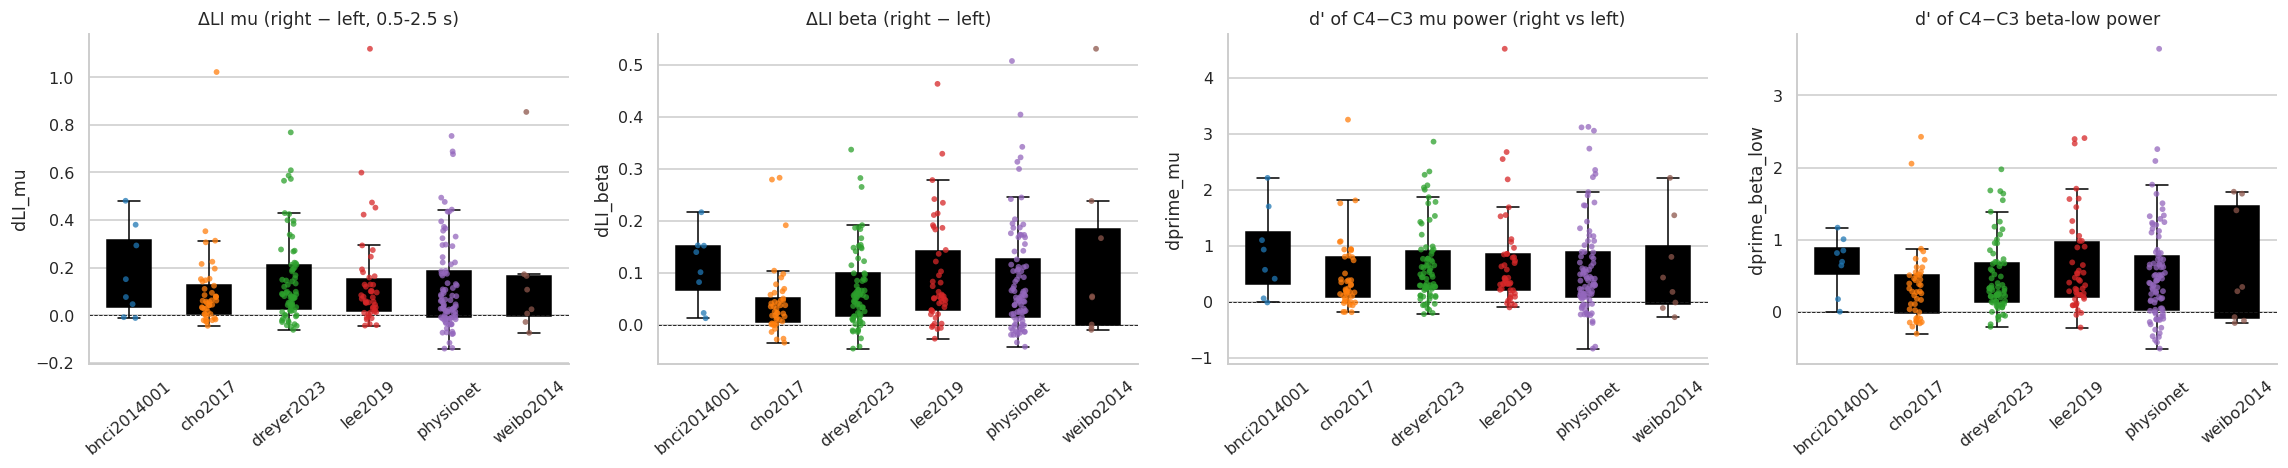

median                                  frac_positive         \
feature     dLI_beta dLI_mu dprime_beta_low dprime_mu      dLI_beta dLI_mu   
dataset                                                                      
bnci2014001    0.121  0.114           0.755     0.750         1.000  0.750   
cho2017        0.029  0.057           0.283     0.228         0.886  0.795   
dreyer2023     0.055  0.088           0.294     0.487         0.877  0.836   
lee2019        0.055  0.072           0.418     0.398         0.891  0.848   
physionet      0.055  0.046           0.435     0.376         0.809  0.697   
weibo2014      0.054  0.066           0.316     0.303         0.750  0.750   

                                      sign_test_p                         \
feature     dprime_beta_low dprime_mu    dLI_beta dLI_mu dprime_beta_low   
dataset                                                                    
bnci2014001           1.000     0.875       0.008  0.289           0.008   
cho2017               0.727     0.795       0.000  0.000           0.004   
dreyer2023            0.904     0.890       0.000  0.000           0.000   
lee2019               0.935     0.913       0.000  0.000           0.000   
physionet             0.775     0.798       0.000  0.000           0.000   
weibo2014             0.625     0.625       0.289  0.289           0.727   

                       
feature     dprime_mu  
dataset                
bnci2014001     0.070  
cho2017         0.000  
dreyer2023      0.000  
lee2019         0.000  
physionet       0.000  
weibo2014       0.727

  saved 07_task_signal_by_dataset.csv
SIGN CHECK: all datasets have positive median ΔLI (consistent label/hemisphere mapping)


In [22]:
# Figure 7b: subject-level task-signal strength and sign consistency
win = (T_ENV >= 0.5) & (T_ENV <= 2.5)
dLI = np.nanmean((LI[:, :, 1] - LI[:, :, 0])[:, :, win], axis=-1)            # (nsub, 2 bands)

# trial-level effect size of the C4-C3 band-power asymmetry, per subject (descriptors from the raw view)
def lat_dprime(bname):
    cols = {c: DESC_NAMES.index(f"{bname}:{c}") for c in ("C3", "C4")}
    asym = DESC["raw"][:, cols["C4"]] - DESC["raw"][:, cols["C3"]]
    out = np.full(len(SUBJ_E), np.nan)
    for i in range(len(SUBJ_E)):
        a, yy = asym[_OFF[i]:_OFF[i + 1]], META["y"].to_numpy()[_OFF[i]:_OFF[i + 1]]
        r, l = a[yy == 1], a[yy == 0]
        if len(r) > 2 and len(l) > 2:
            sp = np.sqrt(((len(r) - 1) * r.var(ddof=1) + (len(l) - 1) * l.var(ddof=1)) / (len(r) + len(l) - 2))
            out[i] = (r.mean() - l.mean()) / (sp + 1e-12)
    return out
task = SUBJ_E[["dataset", "subject_key"]].copy()
task["dLI_mu"], task["dLI_beta"] = dLI[:, 0], dLI[:, 1]
task["dprime_mu"], task["dprime_beta_low"] = lat_dprime("mu"), lat_dprime("beta_low")
fig, ax = plt.subplots(1, 4, figsize=(21, 4.4))
for a, c, t in zip(ax, ["dLI_mu", "dLI_beta", "dprime_mu", "dprime_beta_low"],
                   ["ΔLI mu (right − left, 0.5-2.5 s)", "ΔLI beta (right − left)", "d' of C4−C3 mu power (right vs left)", "d' of C4−C3 beta-low power"]):
    strip_box(a, task, c, t); a.axhline(0, color="k", lw=.6, ls="--")
fig.tight_layout(); save_fig(fig, "F07b_task_signal_strength"); plt.show()

rows = []
for d in DATASETS:
    g = task[task["dataset"] == d]
    for c in ["dLI_mu", "dLI_beta", "dprime_mu", "dprime_beta_low"]:
        v = g[c].dropna().to_numpy()
        rows.append({"dataset": d, "feature": c, "n_subj": len(v), "median": np.median(v), "frac_positive": (v > 0).mean(),
                     "sign_test_p": spst.binomtest(int((v > 0).sum()), len(v), .5).pvalue if len(v) else np.nan})
task_tab = pd.DataFrame(rows).pivot(index="dataset", columns="feature", values=["median", "frac_positive", "sign_test_p"]).round(3)
display(task_tab); save_table(task_tab, "07_task_signal_by_dataset")
neg = [(d, c) for d in DATASETS for c in ["dLI_mu", "dLI_beta"] if task.loc[task["dataset"] == d, c].median() < 0]
print("SIGN CHECK:", "all datasets have positive median ΔLI (consistent label/hemisphere mapping)" if not neg else f"NEGATIVE median ΔLI in {neg} -> inspect label mapping before trusting accuracy there")

**Reading guide.** `frac_positive` near 0.5 means no consistent lateralization in that dataset at the subject level (weak or unreliable task signal);
well above 0.5 with a small sign-test p means a consistent effect. |d'| gives its size. The datasets' *typical* d' sets a rough ceiling for how well any
decoder can do there, and differences between datasets in this plot are differences in task signal, **not** in nuisance variability — they can't be fixed by a transform.

  saved F07c_dreyer_acq_vs_feedback.png


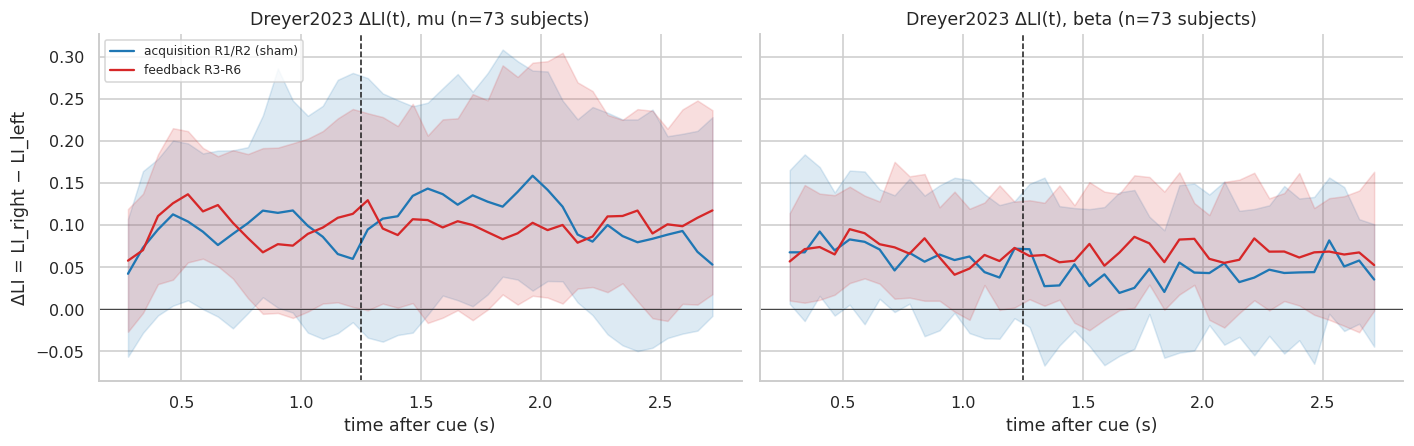

,acq_early,acq_late,fb_early,fb_late
mu,0.134,0.150,0.133,0.162
beta,0.067,0.043,0.078,0.080


  saved 07c_dreyer_acq_vs_feedback.csv
If fb_late exceeds acq_late while fb_early ~ acq_early, the extra late signal appears only after feedback onset -> consistent with the feedback confound.


In [23]:
# Figure 7c: Dreyer acquisition runs (sham feedback) vs feedback runs -- does the signal change after the 1.25 s feedback onset?
ok_subj = np.isfinite(ENV_ACQ).all(axis=(1, 2, 3, 4)) & np.isfinite(ENV_FB).all(axis=(1, 2, 3, 4)) & (SUBJ_DS == "dreyer2023")
if ok_subj.any():
    LIa, LIf = li_curves(ENV_ACQ[ok_subj]), li_curves(ENV_FB[ok_subj])
    dA, dF = LIa[:, :, 1] - LIa[:, :, 0], LIf[:, :, 1] - LIf[:, :, 0]           # (n, 2 bands, T')
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
    for bi, bn in enumerate(BAND_ENV_NAMES):
        for lab, arr, col in (("acquisition R1/R2 (sham)", dA, "tab:blue"), ("feedback R3-R6", dF, "tab:red")):
            a = arr[:, bi][:, tmask]; med = np.nanmedian(a, 0)
            ax[bi].plot(T_ENV[tmask], med, color=col, label=lab); ax[bi].fill_between(T_ENV[tmask], np.nanpercentile(a, 25, 0), np.nanpercentile(a, 75, 0), color=col, alpha=.15)
        ax[bi].axvline(1.25, color="k", ls="--", lw=1); ax[bi].axhline(0, color="k", lw=.5)
        ax[bi].set(title=f"Dreyer2023 ΔLI(t), {bn} (n={ok_subj.sum()} subjects)", xlabel="time after cue (s)")
    ax[0].set_ylabel("ΔLI = LI_right − LI_left"); ax[0].legend(fontsize=8)
    fig.tight_layout(); save_fig(fig, "F07c_dreyer_acq_vs_feedback"); plt.show()
    late = (T_ENV > 1.5) & (T_ENV <= 2.5); early = (T_ENV >= 0.5) & (T_ENV <= 1.25)
    summ = pd.DataFrame({"acq_early": np.nanmean(dA[:, :, early], -1).mean(0), "acq_late": np.nanmean(dA[:, :, late], -1).mean(0),
                         "fb_early": np.nanmean(dF[:, :, early], -1).mean(0), "fb_late": np.nanmean(dF[:, :, late], -1).mean(0)}, index=BAND_ENV_NAMES).round(3)
    display(summ); save_table(summ, "07c_dreyer_acq_vs_feedback")
    print("If fb_late exceeds acq_late while fb_early ~ acq_early, the extra late signal appears only after feedback onset -> consistent with the feedback confound.")
else:
    print("No Dreyer subjects with both acquisition and feedback runs in the cache.")

### 4.5 Spatial structure

  saved F08a_spatial_profile.png


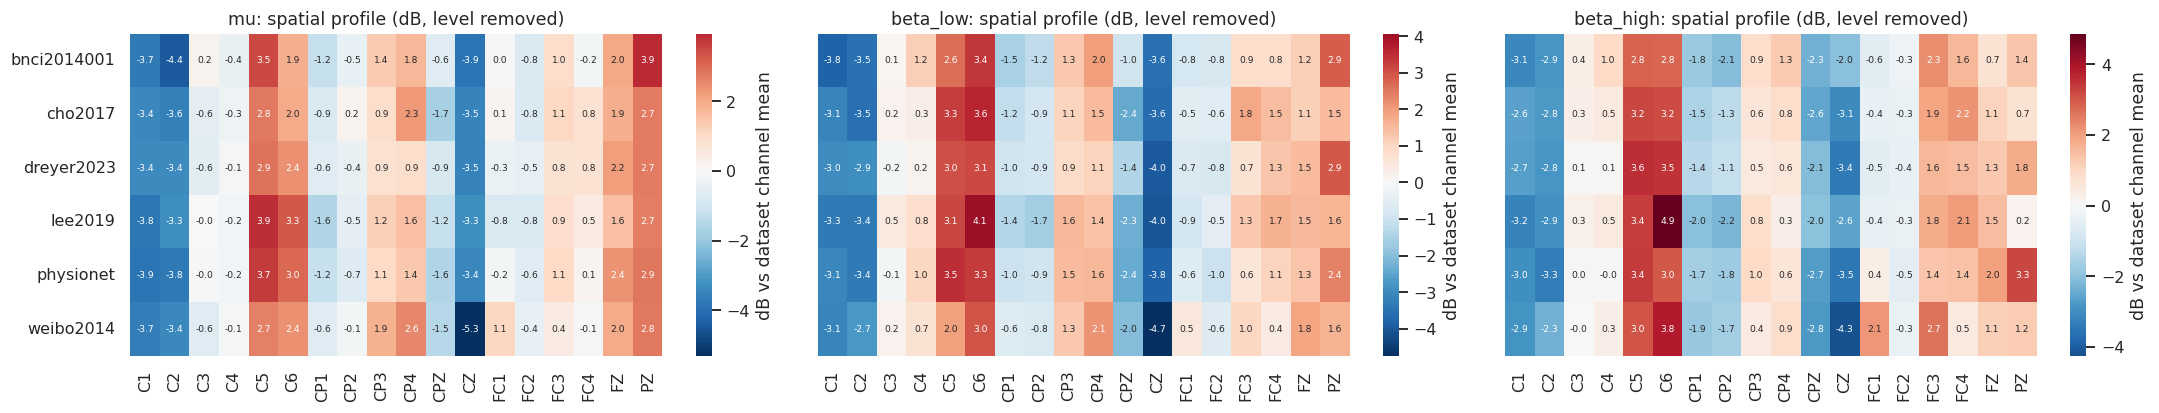

  saved F08b_covariance_geometry.png


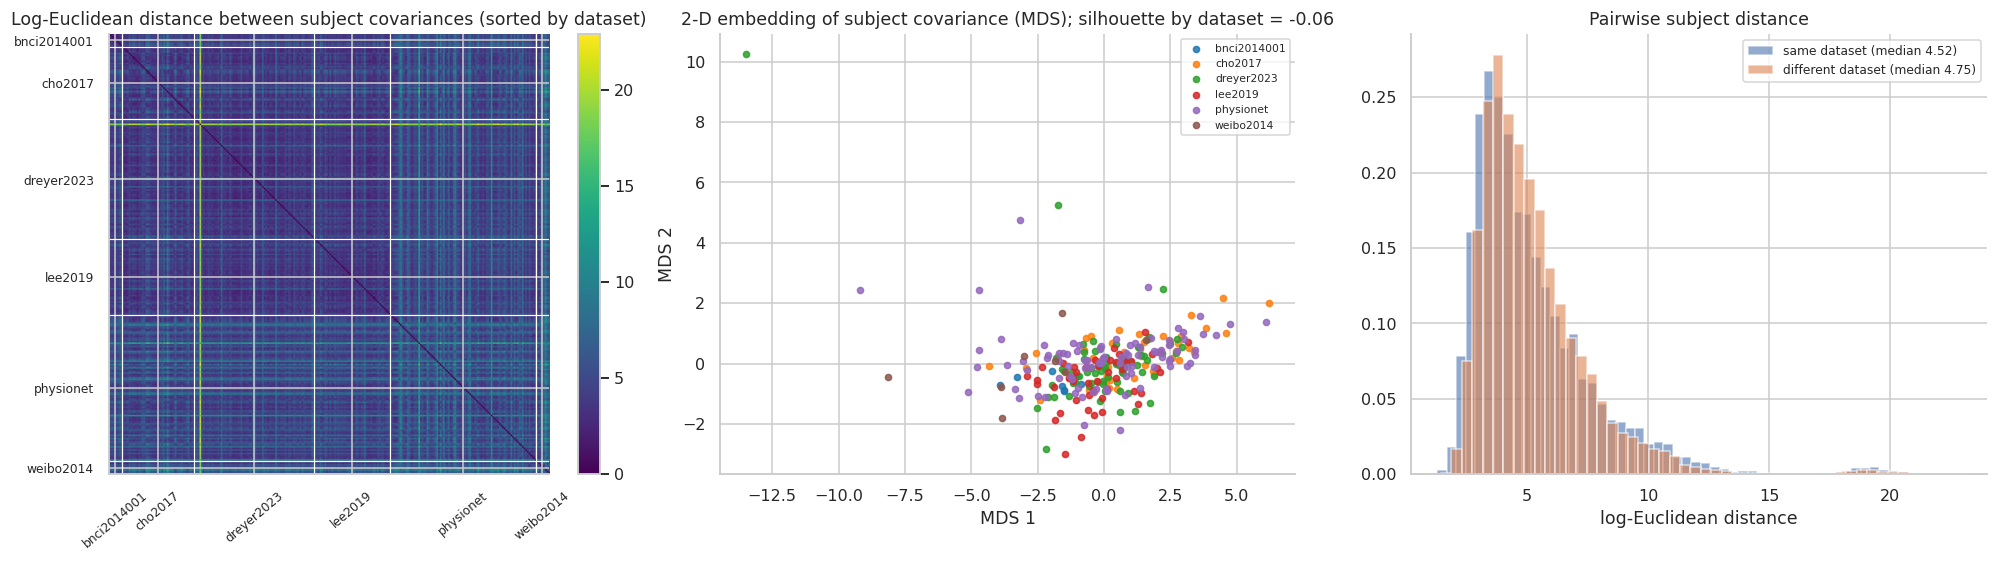

silhouette(dataset) on covariance tangent space = -0.063  (1 = datasets perfectly separated, 0 = overlapping, <0 = mixed)


In [24]:
# Figure 8a: channel topography of band power per dataset (shared channels), relative to the dataset's own channel mean
sub_desc = per_subject(DESC["raw"])                                   # (nsub, 3S)
fig, axes = plt.subplots(1, 3, figsize=(20, 3.9))
for bi, (bn, ax) in enumerate(zip(BANDS, axes)):
    M = np.array([np.median(sub_desc[SUBJ_DS == d][:, bi * S:(bi + 1) * S], 0) for d in DATASETS])
    M = 10 * (M - M.mean(1, keepdims=True))
    sns.heatmap(M, ax=ax, cmap="RdBu_r", center=0, annot=True, fmt=".1f", annot_kws={"fontsize": 6}, xticklabels=SHARED_NAMES,
                yticklabels=DATASETS if bi == 0 else False, cbar_kws={"label": "dB vs dataset channel mean"})
    ax.set_title(f"{bn}: spatial profile (dB, level removed)")
fig.tight_layout(); save_fig(fig, "F08a_spatial_profile"); plt.show()

# Figure 8b: subject-level spatial covariance geometry (log-Euclidean distance between trace-normalized mean covariances)
def logm_spd(C):
    w, V = np.linalg.eigh(C); w = np.maximum(w, w.max() * 1e-9)
    return (V * np.log(w)) @ V.T
iu = np.triu_indices(S)
wts = np.where(iu[0] == iu[1], 1.0, np.sqrt(2.0))
TAN = np.array([(logm_spd(c.astype(np.float64))[iu] * wts) for c in COV])           # (nsub, S(S+1)/2) tangent vectors
from scipy.spatial.distance import pdist, squareform
DIST = squareform(pdist(TAN))
order = np.argsort(SUBJ_DS, kind="stable")
same = SUBJ_DS[:, None] == SUBJ_DS[None, :]; off_diag = ~np.eye(len(SUBJ_DS), dtype=bool)
within, between = DIST[same & off_diag], DIST[~same]
# classical MDS to 2D
Jn = np.eye(len(DIST)) - 1.0 / len(DIST); Bm = -0.5 * Jn @ (DIST ** 2) @ Jn
ev, evec = np.linalg.eigh(Bm); top = np.argsort(ev)[::-1][:2]; XY = evec[:, top] * np.sqrt(np.maximum(ev[top], 0))
sil = silhouette_score(TAN, SUBJ_DS, metric="euclidean")
fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
im = ax[0].imshow(DIST[np.ix_(order, order)], cmap="viridis"); ax[0].set_title("Log-Euclidean distance between subject covariances (sorted by dataset)")
bounds = np.cumsum([np.sum(SUBJ_DS == d) for d in DATASETS])
for b in bounds[:-1]: ax[0].axhline(b - .5, color="w", lw=.8); ax[0].axvline(b - .5, color="w", lw=.8)
_mid = (np.concatenate([[0], bounds[:-1]]) + bounds) / 2 - .5
ax[0].set_xticks(_mid); ax[0].set_xticklabels(DATASETS, rotation=40, fontsize=8); ax[0].set_yticks(_mid); ax[0].set_yticklabels(DATASETS, fontsize=8)
plt.colorbar(im, ax=ax[0], fraction=.046)
for d in DATASETS:
    m = SUBJ_DS == d; ax[1].scatter(XY[m, 0], XY[m, 1], s=16, color=PALETTE[d], label=d, alpha=.85)
ax[1].legend(fontsize=7); ax[1].set(title=f"2-D embedding of subject covariance (MDS); silhouette by dataset = {sil:.2f}", xlabel="MDS 1", ylabel="MDS 2")
ax[2].hist(within, bins=50, density=True, alpha=.6, label=f"same dataset (median {np.median(within):.2f})"); ax[2].hist(between, bins=50, density=True, alpha=.6, label=f"different dataset (median {np.median(between):.2f})")
ax[2].legend(fontsize=8); ax[2].set(title="Pairwise subject distance", xlabel="log-Euclidean distance")
fig.tight_layout(); save_fig(fig, "F08b_covariance_geometry"); plt.show()
print(f"silhouette(dataset) on covariance tangent space = {sil:.3f}  (1 = datasets perfectly separated, 0 = overlapping, <0 = mixed)")

**Reading guide.** The spatial profile removes the dataset's own channel mean, so what remains is *topography*: if profiles differ, a per-channel gain vector (Section 7) is a candidate adapter.
In the covariance geometry, a high silhouette with a large between-vs-within gap means the subject-level second-order statistics already identify the dataset — which is exactly what
Euclidean Alignment (Section 6) is designed to remove. This analysis is subject-level, so it uses all of each subject's trials.

### 4.6 How much of each feature's variance is dataset, subject, or trial?

Nested variance partition (method of moments): `total = dataset + subject-within-dataset + trial residual`, with the subject component corrected for the sampling noise of
subject means. Confidence intervals come from resampling **subjects within each dataset**. The dataset share is the part a dataset-level adapter could in principle remove;
the subject share is the part only a per-subject (transductive) transform or a learned invariance can address; the trial share is irreducible noise for this purpose.

,dataset,subject,trial,dataset_lo,dataset_hi,subject_lo,subject_hi
feature,,,,,,,
log_rms,0.927,0.057,0.016,0.920,0.938,0.047,0.065
logP_mu,0.894,0.083,0.022,0.884,0.908,0.069,0.093
logP_beta_low,0.939,0.049,0.012,0.932,0.947,0.041,0.056
logP_beta_high,0.933,0.054,0.013,0.925,0.943,0.045,0.061
mu_over_beta,0.061,0.663,0.276,0.033,0.140,0.596,0.695
peak_hz,0.006,0.332,0.662,0.005,0.024,0.286,0.370
tilt,0.045,0.609,0.346,0.023,0.096,0.545,0.648
centroid_hz,0.052,0.660,0.289,0.035,0.114,0.594,0.695
entropy,0.061,0.636,0.302,0.028,0.146,0.546,0.678


  saved 09_variance_partition.csv
  saved F09_variance_partition.png


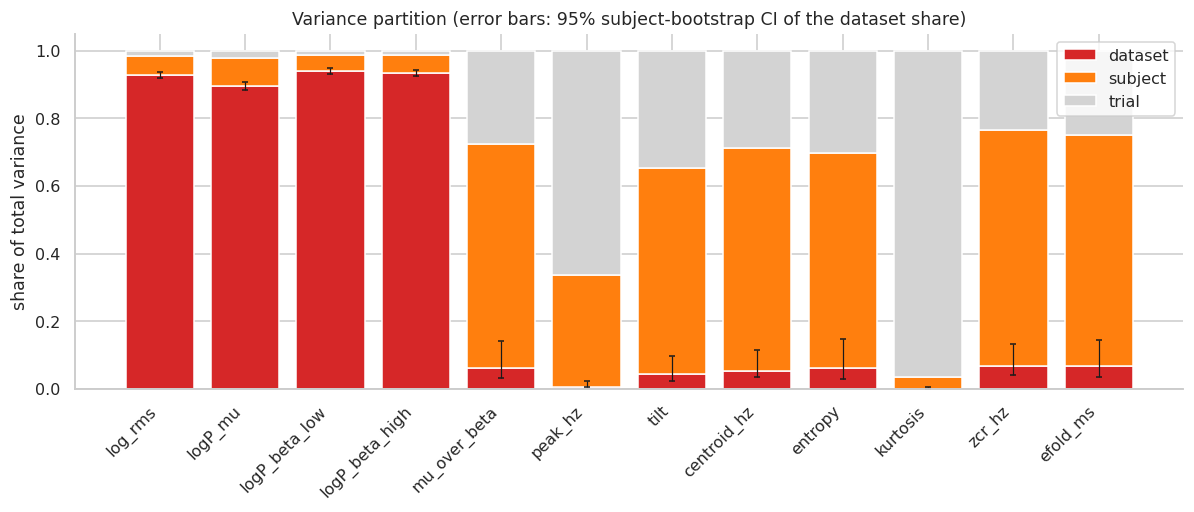

In [25]:
def vp_stats(values):
    s = np.add.reduceat(values.astype(np.float64), _OFF[:-1]); s2 = np.add.reduceat(values.astype(np.float64) ** 2, _OFF[:-1])
    n = SUBJ_E["n"].to_numpy().astype(np.float64); m = s / n
    return n, m, np.maximum(s2 - n * m ** 2, 0.0)

def vp_shares(ds_codes, n, m, ss):
    N, mu = n.sum(), (n * m).sum() / n.sum(); Vds = Vbs = 0.0; D = 0
    for d in np.unique(ds_codes):
        i = ds_codes == d; D += 1; Nd = n[i].sum(); mud = (n[i] * m[i]).sum() / Nd
        Vds += Nd * (mud - mu) ** 2; Vbs += (n[i] * (m[i] - mud) ** 2).sum()
    Vds, Vbs = Vds / N, Vbs / N
    resid = ss.sum() / max((n - 1).sum(), 1)
    Vsub = max(Vbs - (len(n) - D) * resid / N, 0.0)
    tot = Vds + Vsub + resid
    return np.array([Vds, Vsub, resid]) / tot

SUBJ_DS_CODE = np.array([DATASETS.index(d) for d in SUBJ_DS])
def partition_with_ci(values, n_boot=ACFG.n_boot, seed=ACFG.seed):
    n, m, ss = vp_stats(values); point = vp_shares(SUBJ_DS_CODE, n, m, ss)
    rng = np.random.default_rng(seed); boots = []
    groups = [np.where(SUBJ_DS_CODE == k)[0] for k in range(len(DATASETS))]
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(g, size=len(g), replace=True) for g in groups])
        boots.append(vp_shares(SUBJ_DS_CODE[idx], n[idx], m[idx], ss[idx]))
    boots = np.array(boots)
    return point, np.percentile(boots, 2.5, 0), np.percentile(boots, 97.5, 0)

VP_FEATURES = ["log_rms", "logP_mu", "logP_beta_low", "logP_beta_high", "mu_over_beta", "peak_hz", "tilt", "centroid_hz", "entropy",
               "kurtosis", "zcr_hz", "efold_ms"]
vp_rows = []
_const = [f_ for f_ in VP_FEATURES if SC[f_].std() < 1e-9]
if _const:
    print("WARNING: zero-variance feature(s) dropped from the variance partition:", _const)
VP_FEATURES = [f_ for f_ in VP_FEATURES if f_ not in _const]
for f_ in VP_FEATURES:
    pt, lo, hi = partition_with_ci(SC[f_].to_numpy())
    vp_rows.append({"feature": f_, "dataset": pt[0], "subject": pt[1], "trial": pt[2], "dataset_lo": lo[0], "dataset_hi": hi[0],
                    "subject_lo": lo[1], "subject_hi": hi[1]})
VP = pd.DataFrame(vp_rows).set_index("feature")
display(VP.round(3)); save_table(VP, "09_variance_partition")
fig, ax = plt.subplots(figsize=(11, 4.8)); bot = np.zeros(len(VP))
for comp, col in (("dataset", "tab:red"), ("subject", "tab:orange"), ("trial", "lightgrey")):
    ax.bar(range(len(VP)), VP[comp], bottom=bot, color=col, label=comp); bot += VP[comp].to_numpy()
ax.errorbar(range(len(VP)), VP["dataset"], yerr=[VP["dataset"] - VP["dataset_lo"], VP["dataset_hi"] - VP["dataset"]], fmt="none", ecolor="k", capsize=2, lw=.8)
ax.set_xticks(range(len(VP))); ax.set_xticklabels(VP.index, rotation=45, ha="right"); ax.set(ylabel="share of total variance", title="Variance partition (error bars: 95% subject-bootstrap CI of the dataset share)")
ax.legend(); fig.tight_layout(); save_fig(fig, "F09_variance_partition"); plt.show()

**Reading guide.** Features with a large red (dataset) share are where a dataset-level template can help; features that are mostly orange (subject) need per-subject
handling or invariance learning; features that are mostly grey carry little structure at all. Compare `logP_*` (scale-sensitive) with `mu_over_beta` (scale-free):
if the dataset share collapses for the ratio, the dataset signature is a gain effect, which is the easiest kind to remove.

## Section 5 — How strongly does each feature family identify the dataset?

If a classifier can name the dataset from a feature family on **held-out subjects**, that family carries a dataset signature that a downstream model can exploit as a
shortcut. Folds are grouped by subject and stratified by dataset (`StratifiedGroupKFold`); trials are capped per subject (`cap_per_subject_decode`) so large subjects do not dominate.
Chance for 6 balanced classes is balanced accuracy ≈ 0.167. Covariance and channel-mask rows are **subject-level** (one sample per subject).

In [26]:
# Decoding utilities
from sklearn.model_selection import StratifiedKFold

def _cap_idx(cap, seed):
    rng, out = np.random.default_rng(seed), []
    for i in range(len(SUBJ_E)):
        ids = np.arange(_OFF[i], _OFF[i + 1])
        out.append(np.sort(rng.choice(ids, cap, replace=False)) if len(ids) > cap else ids)
    return np.concatenate(out)

CAP_DEC, CAP_CLS = _cap_idx(ACFG.cap_per_subject_decode, ACFG.seed), _cap_idx(ACFG.cap_per_subject_class, ACFG.seed + 1)
CAP_NULL = _cap_idx(ACFG.cap_per_subject_null, ACFG.seed + 2)
SUBJ_KEY, Y_ALL = META["subject_key"].to_numpy(), META["y"].to_numpy()
N_DS = len(DATASETS)

def make_clf():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=300, C=1.0, class_weight="balanced"))

# ---- transforms: fit on TRAIN subjects only; apply to any rows. Each declares what it needs from the target.
class TxIdentity:
    name, scope = "identity", "inductive"
    def fit(self, X, m): return None
    def apply(self, st, X, m): return X

class TxSubjectStd:
    """Per-subject feature standardization using that subject's own (unlabeled) trials."""
    name, scope = "subject-standardize", "subject-transductive"
    def fit(self, X, m): return None
    def apply(self, st, X, m):
        keys, inv = np.unique(m["subject_key"].to_numpy(), return_inverse=True)
        cnt = np.bincount(inv).astype(np.float64)[:, None]
        mu = np.zeros((len(keys), X.shape[1])); np.add.at(mu, inv, X); mu /= cnt
        var = np.zeros_like(mu); np.add.at(var, inv, (X - mu[inv]) ** 2); sd = np.sqrt(var / np.maximum(cnt - 1, 1)) + 1e-6
        return (X - mu[inv]) / sd[inv]

class TxDatasetCenter:
    """Per-dataset mean/std fitted on train subjects, applied using the (true) dataset label of each row."""
    name, scope = "dataset-center", "dataset-oracle"
    def fit(self, X, m):
        st = {}
        for d in np.unique(m["dataset"]):
            r = (m["dataset"].to_numpy() == d); st[d] = (X[r].mean(0), X[r].std(0) + 1e-6)
        return st
    def apply(self, st, X, m):
        out = X.copy()
        for d, (mu, sd) in st.items():
            r = (m["dataset"].to_numpy() == d)
            if r.any(): out[r] = (X[r] - mu) / sd
        return out

def decode_dataset_id(Xmat, tx=None, idx=None, seed=ACFG.seed, shuffle_labels=False):
    idx = CAP_DEC if idx is None else idx
    X, grp, meta = Xmat[idx], SUBJ_KEY[idx], META.iloc[idx]
    ds = DS_CODE[idx].copy()
    if shuffle_labels:                                   # permutation null: shuffle dataset labels across SUBJECTS
        keys = np.unique(grp); perm = dict(zip(keys, np.random.default_rng(seed).permutation([ds[grp == k][0] for k in keys])))
        ds = np.array([perm[g] for g in grp])
    P, fold_ba = np.zeros((len(idx), N_DS)), []
    for tr, te in StratifiedGroupKFold(ACFG.n_splits, shuffle=True, random_state=seed).split(X, ds, grp):
        Xtr, Xte = X[tr], X[te]
        if tx is not None:
            st = tx.fit(Xtr, meta.iloc[tr]); Xtr = tx.apply(st, Xtr, meta.iloc[tr]); Xte = tx.apply(st, Xte, meta.iloc[te])
        clf = make_clf().fit(Xtr, ds[tr]); pr = clf.predict_proba(Xte)
        P[np.ix_(te, clf.classes_)] = pr
        fold_ba.append(balanced_accuracy_score(ds[te], clf.classes_[pr.argmax(1)]))
    pred = P.argmax(1)
    return dict(ba=balanced_accuracy_score(ds, pred), ba_sd=float(np.std(fold_ba, ddof=1)),
                auc=roc_auc_score(ds, P, multi_class="ovr", average="macro"),
                cm=confusion_matrix(ds, pred, labels=range(N_DS)))

def class_info(Xmat, tx=None, idx=None, seed=ACFG.seed):
    """Cross-subject left/right balanced accuracy WITHIN each dataset (subject-grouped folds), macro-averaged over datasets."""
    idx = CAP_CLS if idx is None else idx
    res = {}
    for k, d in enumerate(DATASETS):
        sel = idx[DS_CODE[idx] == k]; X, y, g, m = Xmat[sel], Y_ALL[sel], SUBJ_KEY[sel], META.iloc[sel]
        accs = []
        for tr, te in StratifiedGroupKFold(ACFG.n_splits, shuffle=True, random_state=seed).split(X, y, g):
            Xtr, Xte = X[tr], X[te]
            if tx is not None:
                st = tx.fit(Xtr, m.iloc[tr]); Xtr = tx.apply(st, Xtr, m.iloc[tr]); Xte = tx.apply(st, Xte, m.iloc[te])
            clf = make_clf().fit(Xtr, y[tr]); accs.append(balanced_accuracy_score(y[te], clf.predict(Xte)))
        res[d] = float(np.mean(accs))
    return res, float(np.mean(list(res.values())))
print(f"decode cap: {len(CAP_DEC)} trials | class cap: {len(CAP_CLS)} trials | chance BA (dataset id) = {1/N_DS:.3f}")

decode cap: 21903 trials | class cap: 25483 trials | chance BA (dataset id) = 0.167


  amplitude only (log RMS)                           BA=0.465 ± 0.049  AUC=0.783  (1s)
  spectral shape (PSD, level removed)                BA=0.202 ± 0.059  AUC=0.559  (10s)
  spectral scalars (peak, tilt, centroid, entropy)   BA=0.181 ± 0.077  AUC=0.541  (11s)
  temporal scalars (zcr, e-fold, kurtosis)           BA=0.210 ± 0.057  AUC=0.586  (12s)
  band power, raw view                               BA=0.630 ± 0.072  AUC=0.899  (66s)
  band power, per-trial z view                       BA=0.317 ± 0.062  AUC=0.663  (89s)
  all scalars + band power (raw)                     BA=0.642 ± 0.075  AUC=0.908  (148s)
  permutation null BA over 5 shuffles: [0.193 0.15  0.16  0.155 0.158]  (chance = 0.167; with ~268 subjects a single shuffle can deviate by several points)


,balanced_acc,fold_sd,auc_ovr
permutation null (mean of 5 label shuffles),0.163,0.017,NaN
"spectral scalars (peak, tilt, centroid, entropy)",0.181,0.077,0.541
"spectral shape (PSD, level removed)",0.202,0.059,0.559
"temporal scalars (zcr, e-fold, kurtosis)",0.210,0.057,0.586
"band power, per-trial z view",0.317,0.062,0.663
amplitude only (log RMS),0.465,0.049,0.783
"band power, raw view",0.630,0.072,0.899
all scalars + band power (raw),0.642,0.075,0.908
[subject-level] channel mask only,0.836,0.000,0.947
[subject-level] spatial covariance (tangent),0.930,0.040,0.990


  saved 10_dataset_id_decodability.csv
  saved F10_dataset_identity_decodability.png


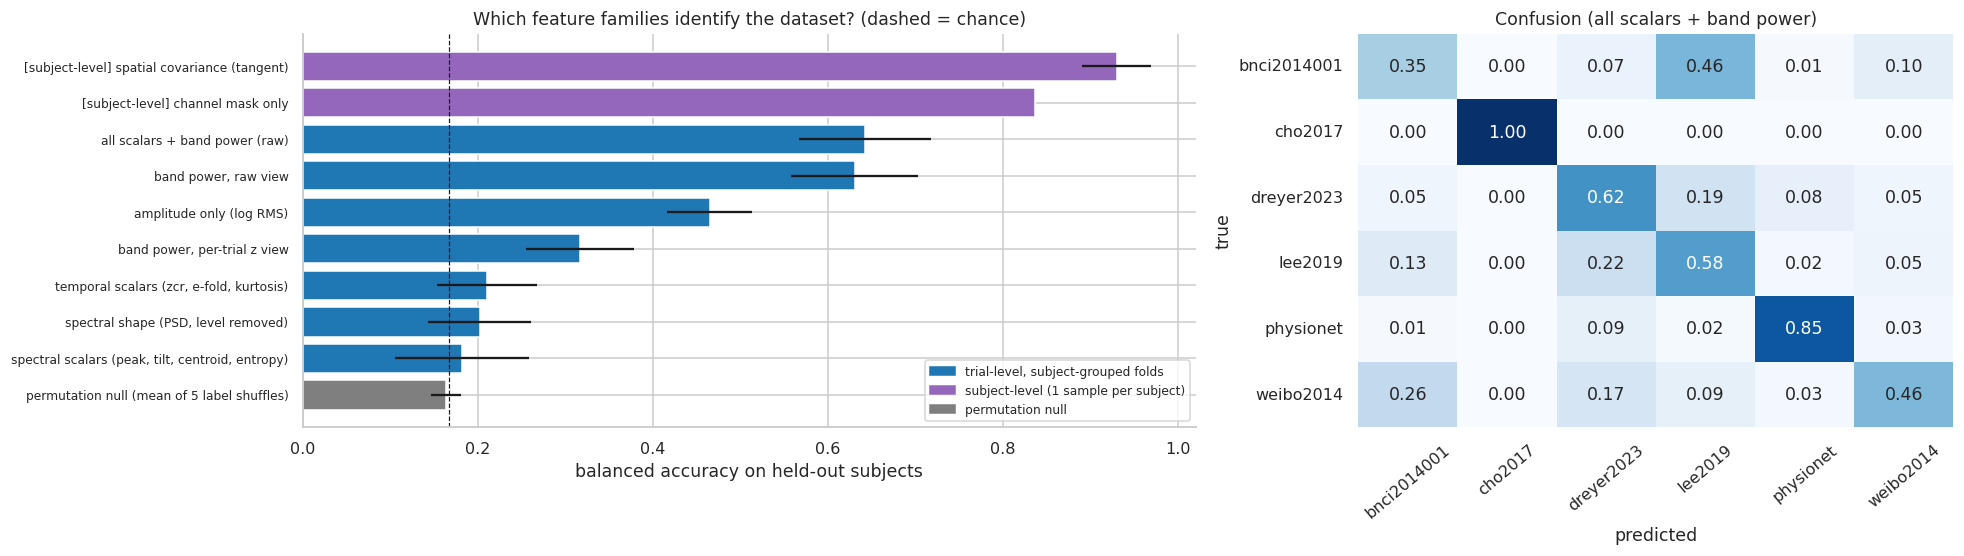

In [27]:
# Figure 10: dataset-identity decodability by feature family
SCALAR_ALL = SC[["log_rms", "kurtosis", "centroid_hz", "entropy", "peak_hz", "tilt", "zcr_hz", "efold_ms"]].to_numpy()
FAMILIES = {
    "amplitude only (log RMS)": SC[["log_rms"]].to_numpy(),
    "spectral shape (PSD, level removed)": PSD_SH - PSD_SH.mean(1, keepdims=True),
    "spectral scalars (peak, tilt, centroid, entropy)": SC[["peak_hz", "tilt", "centroid_hz", "entropy"]].to_numpy(),
    "temporal scalars (zcr, e-fold, kurtosis)": SC[["zcr_hz", "efold_ms", "kurtosis"]].to_numpy(),
    "band power, raw view": DESC["raw"],
    "band power, per-trial z view": DESC["ztrial"],
    "all scalars + band power (raw)": np.hstack([SCALAR_ALL, DESC["raw"]]),
}
t0 = time.time(); fam_res = {}
for name, M in FAMILIES.items():
    fam_res[name] = decode_dataset_id(M); print(f"  {name:<50s} BA={fam_res[name]['ba']:.3f} ± {fam_res[name]['ba_sd']:.3f}  AUC={fam_res[name]['auc']:.3f}  ({time.time()-t0:.0f}s)")
_null = [decode_dataset_id(FAMILIES["all scalars + band power (raw)"], idx=CAP_NULL, seed=ACFG.seed + s, shuffle_labels=True)["ba"] for s in range(ACFG.n_perm_null)]
fam_res[f"permutation null (mean of {ACFG.n_perm_null} label shuffles)"] = dict(ba=float(np.mean(_null)), ba_sd=float(np.std(_null, ddof=1)), auc=np.nan, cm=None)
print(f"  permutation null BA over {ACFG.n_perm_null} shuffles: {np.round(_null, 3)}  (chance = {1/N_DS:.3f}; with ~{len(SUBJ_E)} subjects a single shuffle can deviate by several points)")

# subject-level families
def subject_level_decode(Xs, seed=ACFG.seed):
    y = np.array([DATASETS.index(d) for d in SUBJ_DS]); k = min(ACFG.n_splits, int(np.bincount(y).min()))
    P = np.zeros((len(y), N_DS)); fb = []
    for tr, te in StratifiedKFold(k, shuffle=True, random_state=seed).split(Xs, y):
        clf = make_clf().fit(Xs[tr], y[tr]); pr = clf.predict_proba(Xs[te]); P[np.ix_(te, clf.classes_)] = pr
        fb.append(balanced_accuracy_score(y[te], clf.classes_[pr.argmax(1)]))
    return dict(ba=balanced_accuracy_score(y, P.argmax(1)), ba_sd=float(np.std(fb, ddof=1)), auc=roc_auc_score(y, P, multi_class="ovr", average="macro"),
                cm=confusion_matrix(y, P.argmax(1), labels=range(N_DS)))
MASK_MAT = np.array([CHANNEL_MASKS[d] for d in SUBJ_DS]).astype(float)
fam_res["[subject-level] spatial covariance (tangent)"] = subject_level_decode(TAN)
fam_res["[subject-level] channel mask only"] = subject_level_decode(MASK_MAT)

fam_df = pd.DataFrame({k: {"balanced_acc": v["ba"], "fold_sd": v["ba_sd"], "auc_ovr": v["auc"]} for k, v in fam_res.items()}).T.sort_values("balanced_acc")
display(fam_df.round(3)); save_table(fam_df, "10_dataset_id_decodability")
fig, ax = plt.subplots(1, 2, figsize=(18, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})
cols = ["tab:grey" if ("null" in n) else ("tab:purple" if n.startswith("[subject") else "tab:blue") for n in fam_df.index]
ax[0].barh(range(len(fam_df)), fam_df["balanced_acc"], xerr=fam_df["fold_sd"], color=cols); ax[0].set_yticks(range(len(fam_df))); ax[0].set_yticklabels(fam_df.index, fontsize=8)
ax[0].axvline(1 / N_DS, color="k", ls="--", lw=.8); ax[0].set(xlim=(0, 1.02), xlabel="balanced accuracy on held-out subjects", title="Which feature families identify the dataset? (dashed = chance)")
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color="tab:blue", label="trial-level, subject-grouped folds"), Patch(color="tab:purple", label="subject-level (1 sample per subject)"), Patch(color="tab:grey", label="permutation null")], fontsize=8, loc="lower right")
cm = fam_res["all scalars + band power (raw)"]["cm"]; cmn = cm / cm.sum(1, keepdims=True)
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=DATASETS, yticklabels=DATASETS, cbar=False, ax=ax[1], vmin=0, vmax=1)
ax[1].set(title="Confusion (all scalars + band power)", xlabel="predicted", ylabel="true"); ax[1].tick_params(axis="x", rotation=40)
fig.tight_layout(); save_fig(fig, "F10_dataset_identity_decodability"); plt.show()

**Reading guide.** The permutation-null row (mean of several label shuffles across subjects) must sit near 0.167; a null that stays well above chance means the evaluation itself is leaking. Individual shuffles scatter widely when there are few subjects, which is why several are averaged. A family at ~1.0 is a dataset *fingerprint*
(a model can use it as a shortcut). The confusion matrix shows **which datasets get confused** — those are the ones whose distributions already overlap and are the natural anchors for a shared template.

  saved F11_pairwise_dataset_distance.png


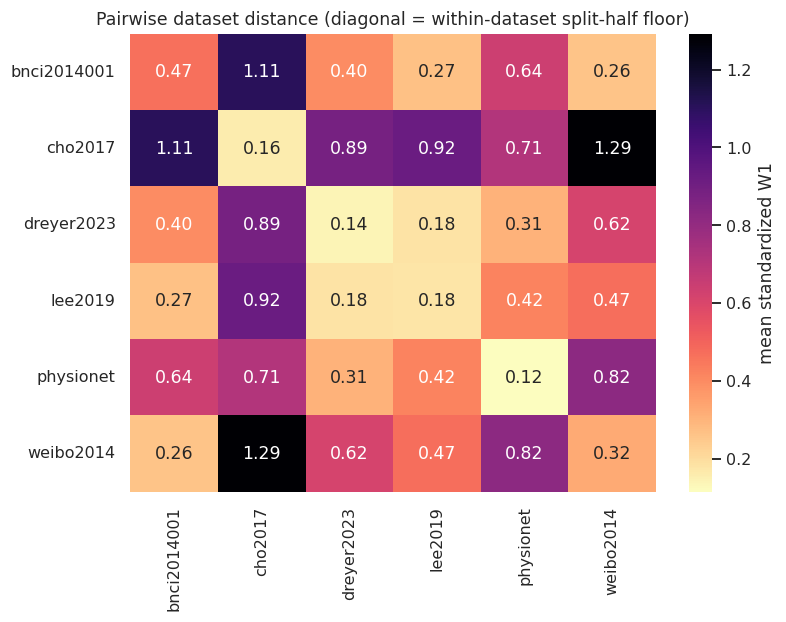

  saved 11_pairwise_dataset_distance.csv
median off-diagonal 0.615 vs median within-dataset floor 0.169


In [28]:
# Figure 11: pairwise dataset distance on scale-free and scale-sensitive scalar features (standardized 1-D Wasserstein, averaged over features)
KEY = ["log_rms", "logP_mu", "logP_beta_low", "logP_beta_high", "mu_over_beta", "peak_hz", "tilt", "centroid_hz", "entropy", "kurtosis", "zcr_hz", "efold_ms"]
_sd = SC[KEY].std(); _const = _sd[_sd < 1e-9].index.tolist()
if _const:
    print("WARNING: zero-variance feature(s) dropped from the pairwise distance:", _const)
KEY = [k for k in KEY if k not in _const]
Zs = ((SC[KEY] - SC[KEY].mean()) / SC[KEY].std()).to_numpy()
rng = np.random.default_rng(ACFG.seed); pools = {}
for k, d in enumerate(DATASETS):
    ids = np.where(DS_CODE == k)[0]; pools[d] = ids[rng.choice(len(ids), min(3000, len(ids)), replace=False)]
def wd(A, B): return float(np.mean([spst.wasserstein_distance(A[:, j], B[:, j]) for j in range(A.shape[1])]))
PW = np.zeros((N_DS, N_DS))
for i, a in enumerate(DATASETS):
    for j, b in enumerate(DATASETS):
        if j > i: PW[i, j] = PW[j, i] = wd(Zs[pools[a]], Zs[pools[b]])
    # diagonal = within-dataset floor: distance between two random halves of the dataset's SUBJECTS
    keys = np.unique(SUBJ_KEY[DS_CODE == i]); vals = []
    for r in range(10):
        h = set(np.random.default_rng(r).permutation(keys)[: len(keys) // 2])
        m1 = np.array([k in h for k in SUBJ_KEY]) & (DS_CODE == i); m2 = ~np.array([k in h for k in SUBJ_KEY]) & (DS_CODE == i)
        i1, i2 = np.where(m1)[0], np.where(m2)[0]
        vals.append(wd(Zs[rng.choice(i1, min(1500, len(i1)), replace=False)], Zs[rng.choice(i2, min(1500, len(i2)), replace=False)]))
    PW[i, i] = np.mean(vals)
PWdf = pd.DataFrame(PW, index=DATASETS, columns=DATASETS)
fig, ax = plt.subplots(figsize=(7.4, 5.8)); sns.heatmap(PWdf, annot=True, fmt=".2f", cmap="magma_r", ax=ax, cbar_kws={"label": "mean standardized W1"})
ax.set_title("Pairwise dataset distance (diagonal = within-dataset split-half floor)"); fig.tight_layout(); save_fig(fig, "F11_pairwise_dataset_distance"); plt.show()
save_table(PWdf, "11_pairwise_dataset_distance")
off = PW[~np.eye(N_DS, dtype=bool)]; print(f"median off-diagonal {np.median(off):.3f} vs median within-dataset floor {np.median(np.diag(PW)):.3f}")

## Section 6 — Transform lab: which standardization shrinks the dataset gap without destroying the task signal?

Each candidate transform is applied to the band-power descriptor (3 bands × shared channels) and scored on two axes, always on **held-out subjects**:

- **dataset-identity balanced accuracy** — lower is better (less dataset shortcut left);
- **cross-subject left/right balanced accuracy**, macro-averaged over datasets — should **not** drop (task information retained).

Fitted parts (dataset means) are fitted on training subjects only inside each fold. The `scope` column states what the transform needs from the target: `inductive`
(nothing), `subject-transductive` (unlabeled trials of the new subject), `dataset-oracle` (the dataset label). Band power alone is a *weak* task feature, so read the second
axis as **relative retention versus the raw view**, not as an accuracy to be proud of.

  T0 raw view                              dataset-id BA=0.630  class BA macro=0.648  (51s)
  T1 per-trial z-score (stored X_z)        dataset-id BA=0.317  class BA macro=0.580  (79s)
  T2 per-trial global-RMS scale            dataset-id BA=0.436  class BA macro=0.651  (98s)
  T3 Euclidean Alignment (subject)         dataset-id BA=0.384  class BA macro=0.653  (106s)
  T4 raw + subject standardization         dataset-id BA=0.167  class BA macro=0.692  (112s)
  T5 raw + dataset centering               dataset-id BA=0.167  class BA macro=0.648  (115s)
  T6 z-trial + subject standardization     dataset-id BA=0.167  class BA macro=0.595  (122s)


,scope,dataset_id_BA,dataset_id_sd,dataset_id_AUC,class_BA_macro,dataset_gap_closed_%,class_BA_delta_vs_raw
transform,,,,,,,
T0 raw view,inductive,0.630,0.072,0.899,0.648,0.000,0.000
T1 per-trial z-score (stored X_z),inductive,0.317,0.062,0.663,0.580,67.578,-0.068
T2 per-trial global-RMS scale,inductive,0.436,0.075,0.770,0.651,41.954,0.003
T3 Euclidean Alignment (subject),subject-transductive,0.384,0.069,0.729,0.653,53.046,0.005
T4 raw + subject standardization,subject-transductive,0.167,0.000,0.500,0.692,100.000,0.044
T5 raw + dataset centering,dataset-oracle,0.167,0.000,0.500,0.648,100.000,0.000
T6 z-trial + subject standardization,subject-transductive,0.167,0.000,0.500,0.595,100.000,-0.054


  saved 12_transform_lab.csv
  saved F12_transform_lab.png


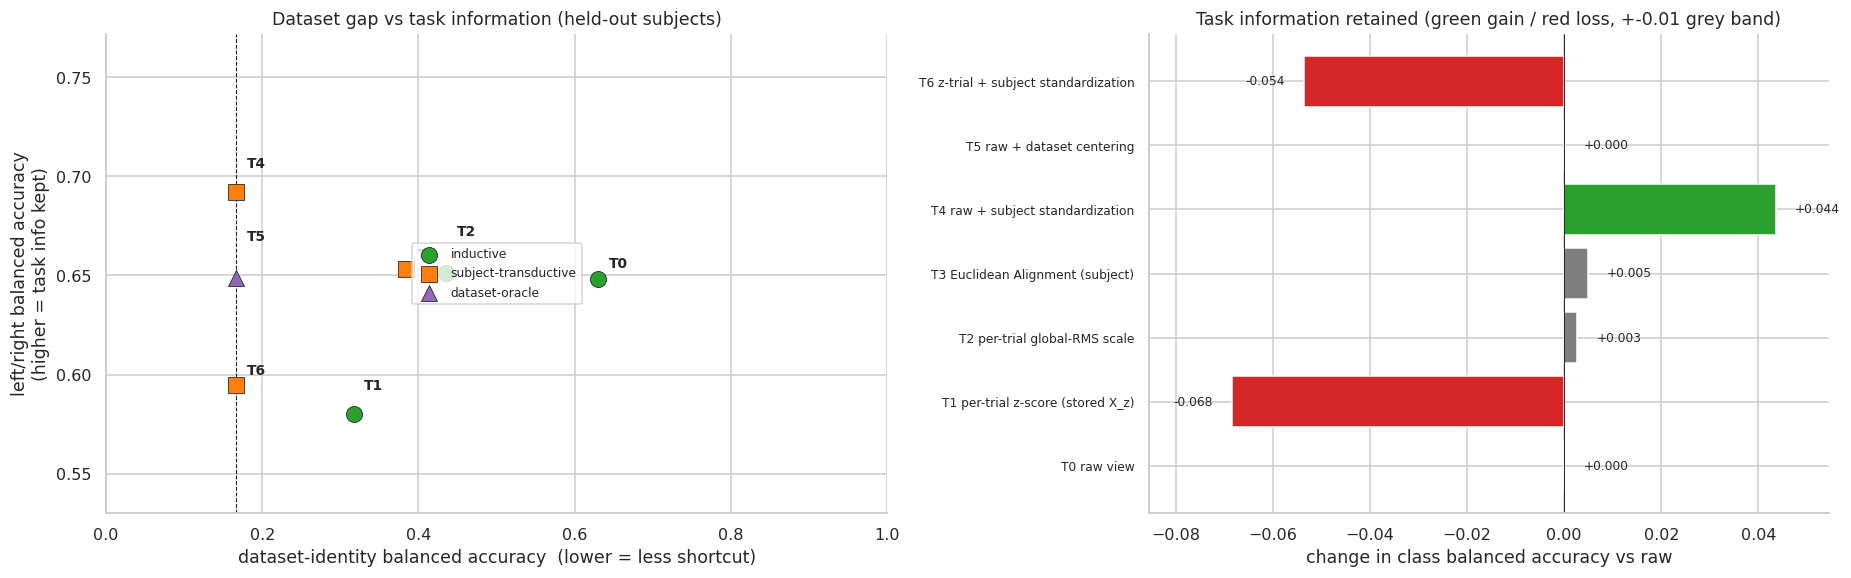

,dataset_share,subject_share,trial_share
view,,,
raw,0.903,0.070,0.027
ztrial,0.038,0.498,0.464
gscale,0.040,0.532,0.428
ea,0.022,0.269,0.709


  saved 12b_variance_share_by_view.csv


In [29]:
# Figure 12: transform lab
LAB = [("T0 raw view", "raw", TxIdentity()), ("T1 per-trial z-score (stored X_z)", "ztrial", TxIdentity()),
       ("T2 per-trial global-RMS scale", "gscale", TxIdentity()), ("T3 Euclidean Alignment (subject)", "ea", TxIdentity()),
       ("T4 raw + subject standardization", "raw", TxSubjectStd()), ("T5 raw + dataset centering", "raw", TxDatasetCenter()),
       ("T6 z-trial + subject standardization", "ztrial", TxSubjectStd())]
SCOPE = {"T3 Euclidean Alignment (subject)": "subject-transductive"}
rows, t0 = [], time.time()
for name, view, tx in LAB:
    dres = decode_dataset_id(DESC[view], tx=tx); cres, cmacro = class_info(DESC[view], tx=tx)
    rows.append({"transform": name, "view": view, "scope": SCOPE.get(name, tx.scope), "dataset_id_BA": dres["ba"], "dataset_id_sd": dres["ba_sd"],
                 "dataset_id_AUC": dres["auc"], "class_BA_macro": cmacro, **{f"class_BA[{d}]": cres[d] for d in DATASETS}})
    print(f"  {name:<40s} dataset-id BA={dres['ba']:.3f}  class BA macro={cmacro:.3f}  ({time.time()-t0:.0f}s)")
LABDF = pd.DataFrame(rows).set_index("transform")
base = LABDF.loc["T0 raw view"]
LABDF["dataset_gap_closed_%"] = 100 * (base["dataset_id_BA"] - LABDF["dataset_id_BA"]) / (base["dataset_id_BA"] - 1 / N_DS)
LABDF["class_BA_delta_vs_raw"] = LABDF["class_BA_macro"] - base["class_BA_macro"]
display(LABDF[["scope", "dataset_id_BA", "dataset_id_sd", "dataset_id_AUC", "class_BA_macro", "dataset_gap_closed_%", "class_BA_delta_vs_raw"]].round(3))
save_table(LABDF, "12_transform_lab")

fig, ax = plt.subplots(1, 2, figsize=(17, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})
mk = {"inductive": "o", "subject-transductive": "s", "dataset-oracle": "^"}
col = {"inductive": "tab:green", "subject-transductive": "tab:orange", "dataset-oracle": "tab:purple"}
for k, (n, r) in enumerate(LABDF.iterrows()):
    ax[0].scatter(r["dataset_id_BA"], r["class_BA_macro"], marker=mk[r["scope"]], color=col[r["scope"]], s=110, edgecolor="k", linewidth=.5, label=r["scope"], zorder=3)
    ax[0].annotate(n.split(" ")[0], (r["dataset_id_BA"], r["class_BA_macro"]), fontsize=9, fontweight="bold",
                   xytext=(7, 7 + 9 * (k % 3)), textcoords="offset points", zorder=4)
ax[0].axvline(1 / N_DS, color="k", ls="--", lw=.7)
ax[0].set(xlabel="dataset-identity balanced accuracy  (lower = less shortcut)", ylabel="left/right balanced accuracy\n(higher = task info kept)",
          title="Dataset gap vs task information (held-out subjects)")
h, l = ax[0].get_legend_handles_labels(); u = dict(zip(l, h)); ax[0].legend(u.values(), u.keys(), fontsize=8, loc="center")
ax[0].set_ylim(LABDF["class_BA_macro"].min() - 0.05, min(1.08, LABDF["class_BA_macro"].max() + 0.08)); ax[0].set_xlim(0, 1.0)
vals = LABDF["class_BA_delta_vs_raw"].to_numpy()
ax[1].barh(range(len(LABDF)), vals, color=["tab:red" if v < -0.01 else "tab:green" if v > 0.01 else "tab:grey" for v in vals])
for k, v in enumerate(vals):
    ax[1].text(v + (0.004 if v >= 0 else -0.004), k, f"{v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax[1].set_yticks(range(len(LABDF))); ax[1].set_yticklabels(LABDF.index, fontsize=8); ax[1].axvline(0, color="k", lw=.6)
ax[1].set_xlim(min(vals.min() * 1.25, -0.05), max(vals.max() * 1.25, 0.05))
ax[1].set(xlabel="change in class balanced accuracy vs raw", title="Task information retained (green gain / red loss, +-0.01 grey band)")
fig.tight_layout(); save_fig(fig, "F12_transform_lab"); plt.show()

# variance partition of the SAME descriptor under each view: how much dataset variance is left?
vp_view = []
for v in VIEWS:
    M = DESC[v]; shares = np.array([vp_shares(SUBJ_DS_CODE, *vp_stats(M[:, j])) for j in range(M.shape[1])])
    vp_view.append({"view": v, "dataset_share": shares[:, 0].mean(), "subject_share": shares[:, 1].mean(), "trial_share": shares[:, 2].mean()})
VPV = pd.DataFrame(vp_view).set_index("view"); display(VPV.round(3)); save_table(VPV, "12b_variance_share_by_view")

**Reading guide.** A good *inductive* standardizer sits to the **left** (less dataset identity) at **no loss** of class information. Subject-standardization and Euclidean
Alignment usually shift further left but are *transductive*: they only apply if you can collect unlabeled trials from each new subject, which must be stated explicitly
in any claim about zero-shot transfer. `dataset-center` is an oracle upper bound for what pure mean-matching can achieve, not a deployable transform. A transform that removes between-channel amplitude ratios (per-channel z-score) can erase task information carried by power *asymmetry* between channels; the right panel is the check for that.
The variance table shows the same story per view: the mean dataset share of variance over the 54 descriptors.

  P0 log-PSD (level + shape)                   BA=0.482
  P1 shape only (per-trial gain removed)       BA=0.202
  P2 shape, tilt removed                       BA=0.200
  P3 log-PSD + subject standardization         BA=0.167
  P4 shape + dataset centering                 BA=0.167


,scope,dataset_id_BA,dataset_id_sd,dataset_id_AUC
transform,,,,
P0 log-PSD (level + shape),inductive,0.482,0.055,0.806
P1 shape only (per-trial gain removed),inductive,0.202,0.059,0.559
"P2 shape, tilt removed",inductive,0.200,0.061,0.526
P3 log-PSD + subject standardization,subject-transductive,0.167,0.000,0.500
P4 shape + dataset centering,dataset-oracle,0.167,0.000,0.500


  saved 13_spectral_shape_transforms.csv
  saved F13_spectral_shape_transforms.png


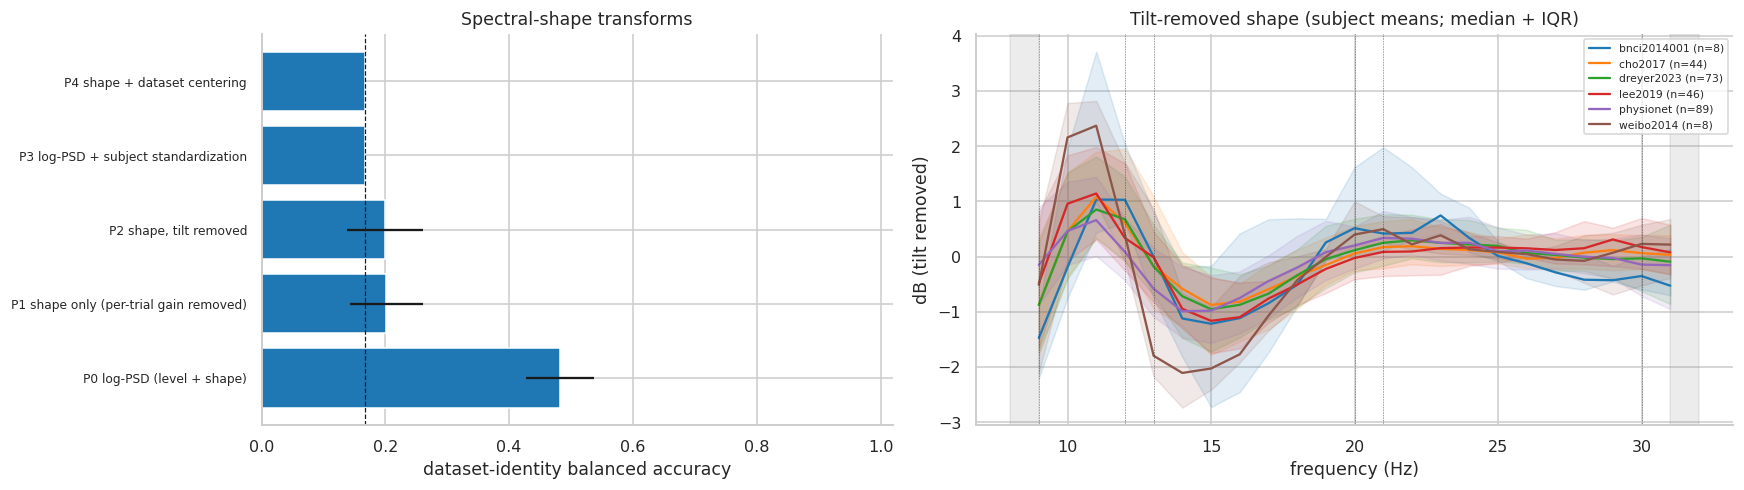

In [30]:
# Figure 13: spectral-SHAPE transforms evaluated on the shared-channel log-PSD (23 bins, 9-31 Hz)
lf = np.log10(PSD_F); lfc = lf - lf.mean()
P0 = PSD_SH.copy()
P1 = PSD_SH - PSD_SH.mean(1, keepdims=True)                                 # per-trial gain removed (shape only)
slope = (P1 * lfc[None]).sum(1) / (lfc ** 2).sum()
P2 = P1 - slope[:, None] * lfc[None]                                        # + spectral tilt removed (log-log linear trend)
SHAPE_LAB = [("P0 log-PSD (level + shape)", P0, TxIdentity()), ("P1 shape only (per-trial gain removed)", P1, TxIdentity()),
             ("P2 shape, tilt removed", P2, TxIdentity()), ("P3 log-PSD + subject standardization", P0, TxSubjectStd()),
             ("P4 shape + dataset centering", P1, TxDatasetCenter())]
rows = []
for name, M, tx in SHAPE_LAB:
    r = decode_dataset_id(M, tx=tx); rows.append({"transform": name, "scope": tx.scope, "dataset_id_BA": r["ba"], "dataset_id_sd": r["ba_sd"], "dataset_id_AUC": r["auc"]})
    print(f"  {name:<44s} BA={r['ba']:.3f}")
SHDF = pd.DataFrame(rows).set_index("transform"); display(SHDF.round(3)); save_table(SHDF, "13_spectral_shape_transforms")
fig, ax = plt.subplots(1, 2, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1, 1.2]})
ax[0].barh(range(len(SHDF)), SHDF["dataset_id_BA"], xerr=SHDF["dataset_id_sd"], color="tab:blue"); ax[0].set_yticks(range(len(SHDF))); ax[0].set_yticklabels(SHDF.index, fontsize=8)
ax[0].axvline(1 / N_DS, color="k", ls="--", lw=.8); ax[0].set(xlim=(0, 1.02), xlabel="dataset-identity balanced accuracy", title="Spectral-shape transforms")
P2_sub = per_subject(P2); psd_panel(ax[1], P2_sub, "Tilt-removed shape (subject means; median + IQR)", "dB (tilt removed)")
ax[1].legend(fontsize=7); fig.tight_layout(); save_fig(fig, "F13_spectral_shape_transforms"); plt.show()

## Section 7 — Standard template and per-dataset adapters (v1, evaluated on held-out subjects)

A **template** is the target every dataset should look like; an **adapter** is the per-dataset correction that maps a dataset's typical value onto it:

- *level* — a gain (dB) matching the dataset's median amplitude to the template amplitude;
- *spectral shape* — a smooth equalizer curve (dB over 9–31 Hz) matching the dataset's median spectral shape to the template shape;
- *topography* — a per-channel gain (dB) over the shared channels.

The template is the **median over datasets of dataset medians** (macro: no dataset counts more because it has more subjects). Adapters are fitted on **training subjects only**
(5 subject-grouped folds, stratified by dataset) and scored on held-out subjects: the mismatch to the template **before** vs **after** adaptation. After adaptation the dataset offset is gone by
construction, so what remains is the **subject-to-subject variability inside a dataset**, which no dataset-level adapter can reduce — that residual is the honest size of the per-subject problem.
These adapters assume the dataset of a new subject is *known*; for a new dataset they must be estimated from unlabeled data first. This is a **descriptive v1**, not a validated preprocessing step.

before  after  reduction_%
component dataset                                
level_dB  bnci2014001    2.89   2.90        -0.36
          cho2017       27.96   1.28        95.42
          dreyer2023     1.68   1.40        16.63
          lee2019        1.82   2.37       -29.91
          physionet      8.51   3.99        53.14
          weibo2014      1.89   1.69        10.97
shape_dB  bnci2014001    1.61   1.54         4.37
          cho2017        1.14   1.18        -3.95
          dreyer2023     1.26   1.24         1.17
          lee2019        1.30   1.43        -9.59
          physionet      1.22   1.31        -7.32
          weibo2014      1.79   1.54        13.97
topo_dB   bnci2014001    0.65   0.69        -5.08
          cho2017        0.86   0.88        -2.04
          dreyer2023     0.90   0.86         3.82
          lee2019        0.82   0.81         1.03
          physionet      1.13   1.07         5.02
          weibo2014      1.08   1.31       -21.40

  saved 14_adapter_heldout_mismatch.csv
  saved F14_adapters_heldout.png


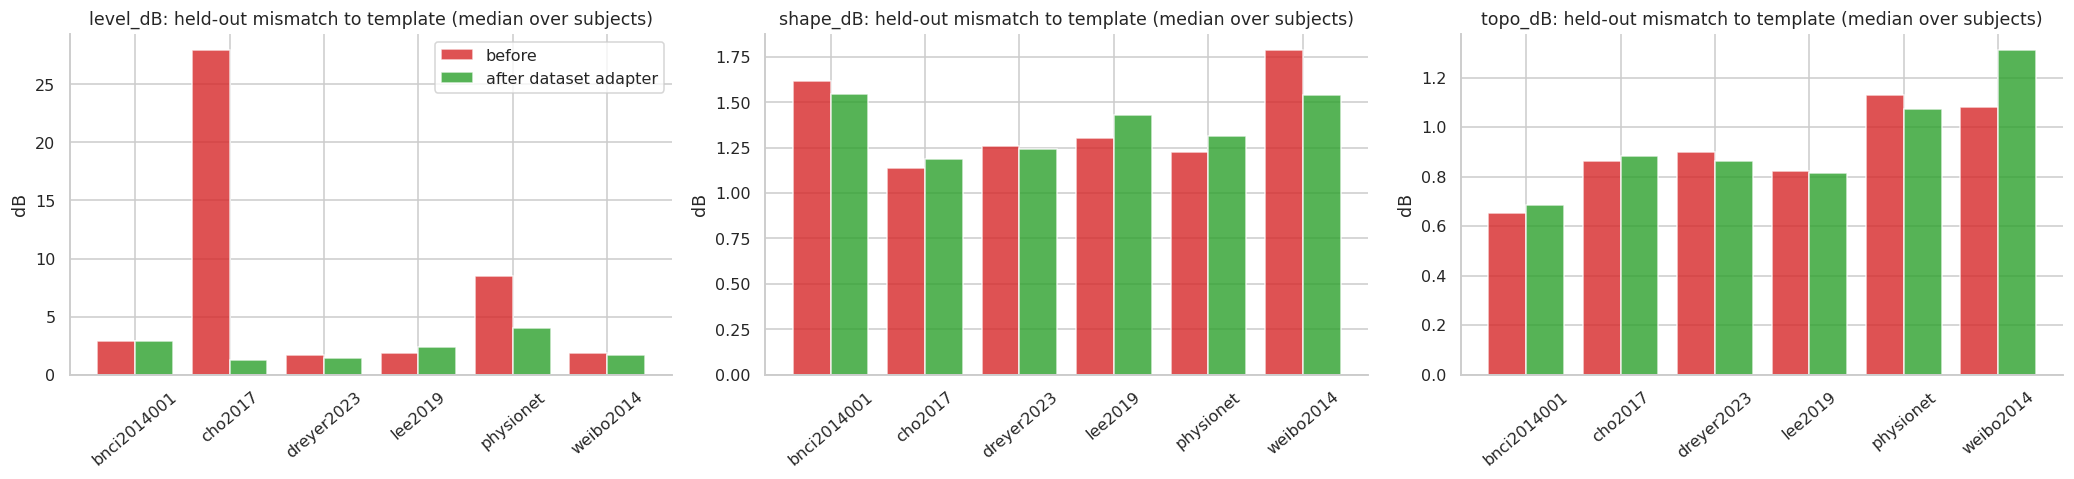

saved template_v1.json
  saved F14b_template_shape.png


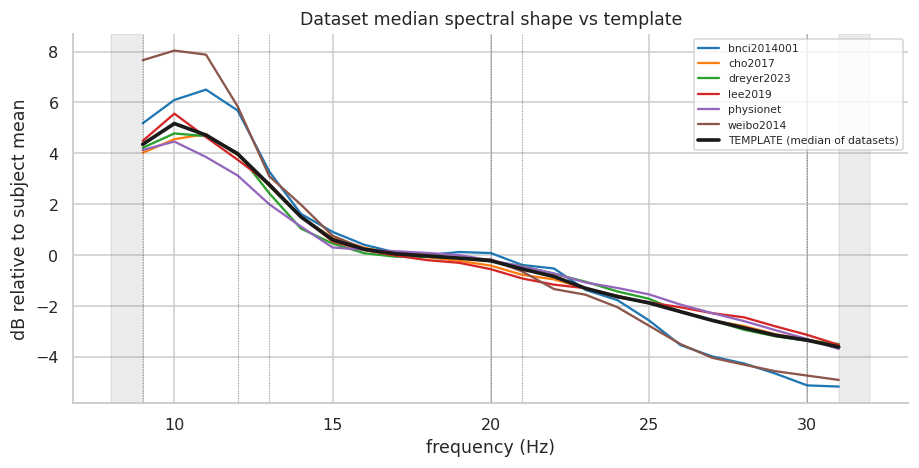

In [31]:
# Template + adapters, with held-out evaluation
lvl_sub = np.array([np.median(SC["log_rms"].to_numpy()[_OFF[i]:_OFF[i + 1]]) for i in range(len(SUBJ_E))])          # log10 uV (amplitude)
lvl_db = 20.0 * lvl_sub                                                                                            # dB (10*log10 of power)
topo_sub = np.stack([sub_desc[:, b * S:(b + 1) * S] for b in range(len(BANDS))], 1).mean(1)                        # (nsub, S) mean log10-power over bands
topo_db = 10 * (topo_sub - topo_sub.mean(1, keepdims=True))                                                        # dB, channel-mean removed
shape_db = 10 * shape_sub                                                                                          # dB, level removed
COMPONENTS = {"level_dB": lvl_db, "shape_dB": shape_db, "topo_dB": topo_db}

def fit_template(ids):
    out = {}
    for name, arr in COMPONENTS.items():
        dmed = {d: np.median(arr[[i for i in ids if SUBJ_DS[i] == d]], axis=0) for d in DATASETS}
        out[name] = (np.median(np.array(list(dmed.values())), axis=0), dmed)
    return out

def rmse(a, b):
    return float(np.sqrt(np.mean((np.atleast_1d(a) - np.atleast_1d(b)) ** 2)))

ysub = np.array([DATASETS.index(d) for d in SUBJ_DS]); k_f = min(ACFG.n_splits, int(np.bincount(ysub).min()))
recs = []
for tr, te in StratifiedKFold(k_f, shuffle=True, random_state=ACFG.seed).split(np.zeros(len(ysub)), ysub):
    fit = fit_template(tr)
    for i in te:
        d = SUBJ_DS[i]
        for comp, arr in COMPONENTS.items():
            T_, dmed = fit[comp]
            # before: distance to the template; after: distance to this dataset's own train median (= what remains once
            # the dataset adapter has moved the dataset median onto the template)
            recs.append({"dataset": d, "component": comp, "before": rmse(arr[i], T_), "after": rmse(arr[i], dmed[d])})
ADP = pd.DataFrame(recs)
adp_tab = ADP.groupby(["component", "dataset"])[["before", "after"]].median()
adp_tab["reduction_%"] = 100 * (1 - adp_tab["after"] / adp_tab["before"])
display(adp_tab.round(2)); save_table(adp_tab, "14_adapter_heldout_mismatch")

fig, ax = plt.subplots(1, 3, figsize=(19, 4.5))
for a, comp in zip(ax, ["level_dB", "shape_dB", "topo_dB"]):
    t = adp_tab.loc[comp].reindex(DATASETS); x = np.arange(len(DATASETS))
    a.bar(x - .2, t["before"], .4, label="before", color="tab:red", alpha=.8); a.bar(x + .2, t["after"], .4, label="after dataset adapter", color="tab:green", alpha=.8)
    a.set_xticks(x); a.set_xticklabels(DATASETS, rotation=40); a.set_title(f"{comp}: held-out mismatch to template (median over subjects)"); a.set_ylabel("dB")
ax[0].legend(); fig.tight_layout(); save_fig(fig, "F14_adapters_heldout"); plt.show()

# final template fitted on ALL eligible (non-locked) subjects, written for reference
full = fit_template(list(range(len(SUBJ_E))))
TEMPLATE = {"version": "template_v1", "descriptive_only": True,
            "fitted_on": {"n_subjects": int(len(SUBJ_E)), "locked_test_excluded": not ACFG.include_locked_test, "preproc_id": layout.get("preproc_id"),
                          "datasets": DATASETS}, "freq_bins_hz": PSD_F.tolist(), "shared_channels": SHARED_NAMES,
            "units": {"level": "dB = 20*log10(RMS in uV)", "shape": "dB relative to subject-mean log-PSD", "topography": "dB relative to channel mean"},
            "template": {"level_db": float(full["level_dB"][0]), "shape_db": full["shape_dB"][0].tolist(), "topography_db": full["topo_dB"][0].tolist()},
            "adapters": {d: {"gain_db": float(full["level_dB"][0] - full["level_dB"][1][d]),
                             "shape_eq_db": (full["shape_dB"][0] - full["shape_dB"][1][d]).tolist(),
                             "channel_gain_db": (full["topo_dB"][0] - full["topo_dB"][1][d]).tolist()} for d in DATASETS},
            "heldout_mismatch_median": {c: {d: {"before": float(adp_tab.loc[(c, d), "before"]), "after": float(adp_tab.loc[(c, d), "after"])} for d in DATASETS}
                                        for c in COMPONENTS},
            "caveats": ["Dataset of a new subject must be known (or estimated from unlabeled data).", "Fitted on the CV pool only; locked test untouched.",
                        "Shape/topography are defined on the shared channels and 9-31 Hz only.", "Not validated as a preprocessing step; use the transform lab (Section 6) for that."]}
(ANALYSIS_ROOT / "template_v1.json").write_text(json.dumps(TEMPLATE, indent=2))
print("saved template_v1.json")
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for d in DATASETS:
    ax.plot(PSD_F, full["shape_dB"][1][d], color=PALETTE[d], label=d)
ax.plot(PSD_F, full["shape_dB"][0], color="k", lw=2.4, label="TEMPLATE (median of datasets)"); band_shade(ax)
ax.set(title="Dataset median spectral shape vs template", xlabel="frequency (Hz)", ylabel="dB relative to subject mean"); ax.legend(fontsize=7)
fig.tight_layout(); save_fig(fig, "F14b_template_shape"); plt.show()

**Reading guide.** `reduction_%` is the share of the *held-out* mismatch to the template that the dataset adapter removes. Large reductions mean the dataset offset dominates and a dataset-level
template is worthwhile; small reductions mean the mismatch is mostly **between subjects inside a dataset** and the remedy must be per-subject (transductive) or learned invariance.
`after` is the floor a dataset-level adapter cannot go below. A **negative** reduction means there is no real dataset offset for that component: the dataset's own median, estimated from few training subjects, is simply a noisier target than the pooled template.

## Section 8 — Dataset fingerprints, decision map, and saved report

In [32]:
# Per-dataset fingerprint table
fp = pd.DataFrame(index=DATASETS)
fp["subjects"] = cohort["subjects"]; fp["trials"] = cohort["trials"]; fp["real_channels"] = cohort["real_channels"]; fp["native_sfreq"] = cohort["native_sfreq"]
sm_all = subj_table(["rms_uv", "logP_mu", "logP_beta_low", "mu_over_beta", "peak_hz", "tilt", "zcr_hz", "efold_ms", "kurtosis"]).groupby("dataset").median(numeric_only=True)
for c in sm_all.columns: fp[f"med_{c}"] = sm_all[c]
for c in ["dLI_mu", "dLI_beta", "dprime_mu"]:
    fp[f"{c}_frac_pos"] = task.groupby("dataset")[c].apply(lambda v: (v.dropna() > 0).mean())
fp["dprime_mu_median"] = task.groupby("dataset")["dprime_mu"].median()
cm_ = fam_res["all scalars + band power (raw)"]["cm"]; fp["dataset_id_recall"] = np.diag(cm_) / cm_.sum(1)
if len(RAW_DF):
    for c in ["std_median_uv", "mains_hz", "mains_peak_db", "aper_slope", "mu_peak_hz", "lowfreq_rel_db", "interchan_corr_median"]:
        fp[f"raw_{c}"] = RAW_DF.groupby("dataset")[c].median()
display(fp.round(3)); save_table(fp, "15_dataset_fingerprint")

,subjects,trials,real_channels,native_sfreq,med_rms_uv,med_logP_mu,med_logP_beta_low,med_mu_over_beta,med_peak_hz,med_tilt,...,dprime_mu_frac_pos,dprime_mu_median,dataset_id_recall,raw_std_median_uv,raw_mains_hz,raw_mains_peak_db,raw_aper_slope,raw_mu_peak_hz,raw_lowfreq_rel_db,raw_interchan_corr_median
bnci2014001,8,2304,22,250.0,2.283000,0.244,0.108,0.308,11.0,-2.007,...,0.875,0.750,0.348,11.944,56.25,1.853,-1.387,10.562,7.028,0.768
cho2017,44,8920,62,512.0,73.543999,3.159,3.065,0.154,11.0,-1.485,...,0.795,0.228,1.000,26782.582,60.00,3.922,-1.864,10.750,20.792,0.326
dreyer2023,73,17520,27,512.0,2.669000,0.270,0.202,0.150,10.0,-1.410,...,0.890,0.487,0.623,95.552,50.00,14.638,-1.376,9.292,14.000,0.683
lee2019,46,9200,48,1000.0,2.507000,0.291,0.096,0.183,10.0,-1.532,...,0.913,0.398,0.575,76.928,60.00,1.928,-1.534,10.500,19.892,0.434
physionet,89,4003,62,160.0,7.580000,1.149,1.029,0.077,10.0,-1.301,...,0.798,0.376,0.849,35.850,60.00,13.098,-1.348,9.750,11.884,0.507
weibo2014,8,1260,58,200.0,3.197000,0.511,0.183,0.491,10.0,-2.003,...,0.625,0.303,0.456,36.049,50.00,6.208,-1.760,10.750,19.574,0.550


  saved 15_dataset_fingerprint.csv


### Decision map: from an observation to a transform to test

| If the analysis shows… | …then the candidate is | Evidence cell | Scope to state in any claim |
|---|---|---|---|
| Datasets differ mainly in overall amplitude; `mu_over_beta` does not separate them | per-trial z-score or global-RMS scale (T1/T2) | F03, F09, F12 | inductive |
| Dataset share of variance is large and shape curves differ in tilt/peak | spectral equalizer or tilt removal toward the template (P2, Section 7) | F04, F13, F14 | dataset known |
| Covariance geometry separates datasets (high silhouette) | Euclidean Alignment (T3) or Riemannian re-centering | F08b, F12 | subject-transductive |
| After all inductive transforms dataset-ID accuracy is still far above chance | invariance must be **learned** (the GRL / alignment losses of Module 3), not preprocessed | F10, F12 | — |
| A transform lowers dataset-ID accuracy **and** class accuracy | reject: it removed task information | F12 right panel | — |
| Subject share ≫ dataset share for the feature | dataset templates cannot fix it; per-subject handling or invariance learning | F09, F14 | — |
| Task-signal strength (d', ΔLI) differs a lot between datasets | per-dataset expectations/ceilings; do not pool metrics across datasets without macro-averaging | F07a/b | — |
| Dreyer late-window signal rises only in feedback runs | exclude `feedback_confounded` trials in the primary analysis | F07c | — |
| Raw mains/aliasing/bandwidth differ strongly | revisit the filter/resample stage of the export, not the model | F02 | — |

In [33]:
# Save a machine-readable summary of the key numbers
report = {
    "export_preproc_id": layout.get("preproc_id"), "locked_test_excluded": not ACFG.include_locked_test, "n_subjects": int(len(SUBJ_E)),
    "n_trials": int(len(META)), "datasets": DATASETS, "shared_channels": SHARED_NAMES, "analysis_config": asdict(ACFG),
    "dataset_id_decodability": {k: {"balanced_acc": float(v["ba"]), "auc": float(v["auc"])} for k, v in fam_res.items()},
    "transform_lab": LABDF[["scope", "dataset_id_BA", "class_BA_macro", "dataset_gap_closed_%", "class_BA_delta_vs_raw"]].round(4).to_dict(orient="index"),
    "variance_partition_mean_over_features": VP[["dataset", "subject", "trial"]].mean().round(4).to_dict(),
    "covariance_silhouette_by_dataset": float(sil), "raw_domain_subjects": int(len(RAW_DF)),
    "sign_check_negative_dLI": [list(x) for x in neg],
}
(ANALYSIS_ROOT / "distribution_report.json").write_text(json.dumps(report, indent=2, default=float))
print("saved distribution_report.json")
print("\nFigures:", *sorted(p.name for p in FIG_DIR.glob("*.png")), sep="\n  ")
print("\nTables:", *sorted(p.name for p in TAB_DIR.glob("*.csv")), sep="\n  ")

saved distribution_report.json

Figures:
  F01_cohort_inventory.png
  F02a_raw_native_scalars.png
  F02b_raw_native_psd.png
  F03_amplitude.png
  F04_psd.png
  F05_band_and_spectral_scalars.png
  F05b_peak_frequency_share.png
  F06_temporal_structure.png
  F07a_lateralization_timecourses.png
  F07b_task_signal_strength.png
  F07c_dreyer_acq_vs_feedback.png
  F08a_spatial_profile.png
  F08b_covariance_geometry.png
  F09_variance_partition.png
  F10_dataset_identity_decodability.png
  F11_pairwise_dataset_distance.png
  F12_transform_lab.png
  F13_spectral_shape_transforms.png
  F14_adapters_heldout.png
  F14b_template_shape.png

Tables:
  01_cohort_by_dataset.csv
  02_raw_native_per_subject.csv
  02_raw_native_summary_median.csv
  03_amplitude_kruskal.csv
  04_psd_level_vs_shape.csv
  05_spectral_kruskal.csv
  06_temporal_kruskal.csv
  07_task_signal_by_dataset.csv
  07c_dreyer_acq_vs_feedback.csv
  09_variance_partition.csv
  10_dataset_id_decodability.csv
  11_pairwise_dataset_distanc